# NumPy for Machine Learning

A Lecture-Complete Course Script for Mathematicians

Prepared with ChatGPT

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# How to Use This Script

This document is designed as a lecture-complete course script for a
mathematically trained audience. It aims to bridge rigorous mathematical
thinking and practical numerical implementation.

The guiding principle of the course is:

> **Mathematics → vectorized formulation → NumPy implementation →
> numerical interpretation**

The intended audience is a group of students who are comfortable with
linear algebra, calculus, basic proof-oriented reasoning, and elementary
Python.

The central didactic choices are the following.

1.  We treat **NumPy** as the computational language of
    finite-dimensional linear algebra.
2.  We treat **pandas** as a data interface rather than as the
    mathematical core.
3.  We implement fundamental machine learning models directly in NumPy
    before mentioning higher-level libraries.
4.  We repeatedly connect formulas to shapes, dimensions, and numerical
    stability.

# Learning Objectives

After working through this script, students should be able to:

- use NumPy arrays as vectors, matrices, and batches of data;
- reason confidently about shapes, axes, and broadcasting;
- distinguish elementwise operations from linear-algebraic operations;
- derive and implement linear regression from first principles;
- implement gradient descent and study its convergence behavior;
- derive and implement logistic regression for binary classification;
- understand the role of feature scaling and data preprocessing;
- implement a simple neural network using matrix operations;
- recognize common sources of numerical instability and shape errors;
- connect abstract mathematics with computational workflows.

# Course Structure

The course is organized as follows.

1.  NumPy as a language for vectors and matrices.
2.  Shapes, slicing, views, copies, and the logic of vectorization.
3.  Linear algebra in NumPy.
4.  Statistics and aggregation.
5.  pandas as a gateway from raw tabular data to numerical arrays.
6.  Linear regression and the normal equation.
7.  Gradient descent and optimization.
8.  Logistic regression and binary cross-entropy.
9.  Data preprocessing and feature engineering.
10. A first neural network in pure NumPy.
11. Numerical stability and debugging strategies.
12. Mini-projects and extensions.

# Mathematical Convention

Throughout the text:

- vectors are written in lowercase, for example $x \in \mathbb{R}^d$;
- matrices are written in uppercase, for example
  $X \in \mathbb{R}^{n \times d}$;
- rows of $X$ usually represent samples;
- columns of $X$ usually represent features.

Thus a dataset with $n$ observations and $d$ features is represented by
a matrix

$$X \in \mathbb{R}^{n \times d}.$$

A parameter vector for a linear model is usually written as

$$w \in \mathbb{R}^d.$$

Predictions then take the form

$$\hat y = Xw.$$

# 1. NumPy as a Computational Model of Linear Algebra

## 1.1 Arrays, vectors, matrices

NumPy arrays are the fundamental data structure of the course. A
one-dimensional array behaves like a vector, and a two-dimensional array
behaves like a matrix.

In [5]:
import numpy as np
x = np.array([1.0, 2.0, 3.0])
A = np.array([
    [1.0, 0.0, 2.0],
    [0.0, 1.0, 1.0]
])

print("x =")
print(x)
print()
print("A =")
print(A)
print()
print("x.shape =", x.shape)
print("A.shape =", A.shape)
print("x.ndim =", x.ndim)
print("A.ndim =", A.ndim)
print("x.dtype =", x.dtype)

x =
[1. 2. 3.]

A =
[[1. 0. 2.]
 [0. 1. 1.]]

x.shape = (3,)
A.shape = (2, 3)
x.ndim = 1
A.ndim = 2
x.dtype = float64


A first important observation is that the shape of a vector in NumPy is
not `(3, 1)` but `(3,)`. This is mathematically convenient in some
places and dangerous in others. Much of good NumPy programming consists
in keeping track of such distinctions.

## 1.2 Column vectors versus one-dimensional arrays

From a mathematical viewpoint, one may want to distinguish between a
vector in $\mathbb{R}^d$ and a column vector in
$\mathbb{R}^{d \times 1}$. NumPy does not force that distinction unless
we create it explicitly.

In [3]:
x = np.array([1.0, 2.0, 3.0])
x_col = x.reshape(-1, 1)
x_row = x.reshape(1, -1)

print("x.shape =", x.shape)
print("x_col.shape =", x_col.shape)
print("x_row.shape =", x_row.shape)
print()
print("x_col =")
print(x_col)
print()
print("x_row =")
print(x_row)

x.shape = (3,)
x_col.shape = (3, 1)
x_row.shape = (1, 3)

x_col =
[[1.]
 [2.]
 [3.]]

x_row =
[[1. 2. 3.]]

In [13]:
print("x.reshape(-1,1) =", x.reshape(-1,1))
print("A.reshape(3,2) =", A.reshape(3,2))
print("A.reshape(-1,2) =", A.reshape(-1,2))
print("A.reshape(-1) =", A.reshape(-1))
print("x.T =", x.T)
print("A.T =", A.T)
np.arange(6).reshape(3,2)



x.reshape(-1,1) = [[1.]
 [2.]
 [3.]]
A.reshape(3,2) = [[1. 0.]
 [2. 0.]
 [1. 1.]]
A.reshape(-1,2) = [[1. 0.]
 [2. 0.]
 [1. 1.]]
A.reshape(-1) = [1. 0. 2. 0. 1. 1.]
x.T = [1. 2. 3.]
A.T = [[1. 0.]
 [0. 1.]
 [2. 1.]]


array([[0, 1],
       [2, 3],
       [4, 5]])

This is one of the most important habits for students: always ask what
the shape of each object is.

## 1.3 Basic arithmetic

In [4]:
x = np.array([1.0, -2.0, 4.0])
y = np.array([3.0, 5.0, -1.0])

print("x + y =", x + y)
print("x - y =", x - y)
print("2 * x =", 2 * x)
print("x / 2 =", x / 2)
print("x ** 2 =", x ** 2)

x + y = [4. 3. 3.]
x - y = [-2. -7.  5.]
2 * x = [ 2. -4.  8.]
x / 2 = [ 0.5 -1.   2. ]
x ** 2 = [ 1.  4. 16.]

These are **elementwise** operations. That distinction matters.
Elementwise multiplication is not the same as matrix multiplication.

## 1.4 Inner product, norms, and basic geometry

In [5]:
x = np.array([1.0, -2.0, 2.0])
y = np.array([3.0, 1.0, -1.0])

inner_1 = x @ y
inner_2 = np.dot(x, y)
norm_l1 = np.sum(np.abs(x))
norm_l2 = np.sqrt(np.sum(x**2))
norm_l2_alt = np.linalg.norm(x)
norm_inf = np.max(np.abs(x))

print("inner_1 =", inner_1)
print("inner_2 =", inner_2)
print("||x||_1 =", norm_l1)
print("||x||_2 =", norm_l2)
print("||x||_2 (np.linalg.norm) =", norm_l2_alt)
print("||x||_inf =", norm_inf)

inner_1 = -1.0
inner_2 = -1.0
||x||_1 = 5.0
||x||_2 = 3.0
||x||_2 (np.linalg.norm) = 3.0
||x||_inf = 2.0

The formula

$$\langle x, y \rangle = \sum_{j=1}^d x_j y_j$$

becomes either `x @ y` or `np.dot(x, y)`.

The Euclidean norm

$$\|x\|_2 = \sqrt{\langle x, x \rangle}$$

can be implemented by hand or by a library function. In a course for
mathematicians it is worth showing both.

## 1.5 Exercise set

1.  Create a vector $x \in \mathbb{R}^5$ of your choice.
2.  Compute $\|x\|_1$, $\|x\|_2$, and $\|x\|_\infty$.
3.  Create another vector $y \in \mathbb{R}^5$ and compute the inner
    product.
4.  Reshape $x$ into a column vector and a row vector.
5.  Explain in words why `x.shape == (5,)` is not the same as
    `x.reshape(5, 1).shape == (5, 1)`.

## 1.6 Worked solution sketch

In [6]:
x = np.array([1.0, -1.0, 2.0, 0.0, 3.0])
y = np.array([2.0, 1.0, -1.0, 4.0, 0.5])

print("||x||_1 =", np.sum(np.abs(x)))
print("||x||_2 =", np.linalg.norm(x))
print("||x||_inf =", np.max(np.abs(x)))
print("<x,y> =", x @ y)
print("column shape =", x.reshape(-1, 1).shape)
print("row shape =", x.reshape(1, -1).shape)

||x||_1 = 7.0
||x||_2 = 3.872983346207417
||x||_inf = 3.0
<x,y> = 0.5
column shape = (5, 1)
row shape = (1, 5)

# 2. Indexing, Slicing, Views, and Copies

## 2.1 One-dimensional indexing

In [7]:
a = np.arange(10)
print("a =", a)
print("a[0] =", a[0])
print("a[3] =", a[3])
print("a[-1] =", a[-1])
print("a[2:7] =", a[2:7])
print("a[:4] =", a[:4])
print("a[::2] =", a[::2])

a = [0 1 2 3 4 5 6 7 8 9]
a[0] = 0
a[3] = 3
a[-1] = 9
a[2:7] = [2 3 4 5 6]
a[:4] = [0 1 2 3]
a[::2] = [0 2 4 6 8]

## 2.2 Two-dimensional indexing

In [8]:
A = np.arange(1, 13).reshape(3, 4)
print("A =")
print(A)
print()
print("A[0, 0] =", A[0, 0])
print("A[1, 2] =", A[1, 2])
print("A[:, 1] =", A[:, 1])
print("A[1, :] =", A[1, :])
print("A[:2, 1:3] =")
print(A[:2, 1:3])

A =
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

A[0, 0] = 1
A[1, 2] = 7
A[:, 1] = [ 2  6 10]
A[1, :] = [5 6 7 8]
A[:2, 1:3] =
[[2 3]
 [6 7]]

For a matrix $A \in \mathbb{R}^{m \times n}$, the expression `A[:, j]`
selects the $j$-th column, whereas `A[i, :]` selects the $i$-th row.

## 2.3 Views versus copies

This topic is essential. A slice often creates a view rather than an
independent object.

In [9]:
a = np.arange(10)
b = a[2:6]

print("Before modification")
print("a =", a)
print("b =", b)

b[0] = 99

print()
print("After modification")
print("a =", a)
print("b =", b)

Before modification
a = [0 1 2 3 4 5 6 7 8 9]
b = [2 3 4 5]

After modification
a = [ 0  1 99  3  4  5  6  7  8  9]
b = [99  3  4  5]

The modification of `b` also changed `a`. This means that `b` was a view
on part of `a`.

To force an actual copy, use `.copy()`.

In [10]:
a = np.arange(10)
c = a[2:6].copy()
c[0] = -7

print("a =", a)
print("c =", c)

a = [0 1 2 3 4 5 6 7 8 9]
c = [-7  3  4  5]

## 2.4 Boolean masks

Boolean indexing is a central tool for data preprocessing.

In [11]:
x = np.array([3.0, -1.0, 2.5, -4.0, 0.0, 7.0])
mask = x > 0

print("x =", x)
print("mask =", mask)
print("x[mask] =", x[mask])

x = [ 3.  -1.   2.5 -4.   0.   7. ]
mask = [ True False  True False False  True]
x[mask] = [3.  2.5 7. ]

For matrices the same logic works rowwise or elementwise depending on
the mask.

In [12]:
X = np.array([
    [1.0, 10.0],
    [-1.0, 20.0],
    [2.0, 30.0],
    [-2.0, 40.0]
])

row_mask = X[:, 0] > 0
print("row_mask =", row_mask)
print("Filtered rows =")
print(X[row_mask])

row_mask = [ True False  True False]
Filtered rows =
[[ 1. 10.]
 [ 2. 30.]]

## 2.5 Exercises

1.  Create a $4 \times 5$ matrix and select its second row and third
    column.
2.  Create a slice of the matrix and verify whether modifying the slice
    changes the original matrix.
3.  Create a copy of the slice and verify that modifying it does not
    change the original matrix.
4.  Use boolean indexing to select all entries of a vector that are
    strictly larger than $1$.
5.  Filter all rows of a matrix whose first component is positive.

## 2.6 Worked example

In [13]:
A = np.arange(20).reshape(4, 5)
print("A =")
print(A)
print()
print("second row =", A[1, :])
print("third column =", A[:, 2])

sub = A[:2, :3]
sub[0, 0] = -100
print()
print("A after modifying a view =")
print(A)

A = np.arange(20).reshape(4, 5)
sub_copy = A[:2, :3].copy()
sub_copy[0, 0] = -100
print()
print("A after modifying a copy =")
print(A)
print("sub_copy =")
print(sub_copy)

A =
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]

second row = [5 6 7 8 9]
third column = [ 2  7 12 17]

A after modifying a view =
[[-100    1    2    3    4]
 [   5    6    7    8    9]
 [  10   11   12   13   14]
 [  15   16   17   18   19]]

A after modifying a copy =
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]]
sub_copy =
[[-100    1    2]
 [   5    6    7]]

# 3. Vectorization and Broadcasting

## 3.1 Why vectorization matters

In machine learning we rarely want to process one data point at a time
in pure Python loops. Instead we formulate operations on full vectors
and matrices.

Suppose we want to evaluate the affine function

$$f(x) = 3x + 2$$

at many points simultaneously.

In [14]:
x = np.linspace(0.0, 1.0, 6)
y = 3 * x + 2

print("x =", x)
print("y =", y)

x = [0.  0.2 0.4 0.6 0.8 1. ]
y = [2.  2.6 3.2 3.8 4.4 5. ]

This is both shorter and faster than a Python loop.

## 3.2 Loop versus vectorized formulation

In [15]:
x = np.linspace(0.0, 1.0, 6)

y_loop = np.empty_like(x)
for i in range(len(x)):
    y_loop[i] = 3 * x[i] + 2

y_vec = 3 * x + 2

print("y_loop =", y_loop)
print("y_vec  =", y_vec)
print("difference =", np.max(np.abs(y_loop - y_vec)))

y_loop = [2.  2.6 3.2 3.8 4.4 5. ]
y_vec  = [2.  2.6 3.2 3.8 4.4 5. ]
difference = 0.0

The vectorized formulation exposes the mathematics more clearly: the
expression looks like the formula itself.

## 3.3 Broadcasting idea

Broadcasting allows NumPy to combine arrays of compatible shape even
when their shapes are not identical.

In [16]:
X = np.array([
    [1.0, 2.0],
    [3.0, 4.0],
    [5.0, 6.0]
])

b = np.array([10.0, 20.0])

print("X =")
print(X)
print()
print("b =", b)
print()
print("X + b =")
print(X + b)

X =
[[1. 2.]
 [3. 4.]
 [5. 6.]]

b = [10. 20.]

X + b =
[[11. 22.]
 [13. 24.]
 [15. 26.]]

The vector `b` is broadcast across all rows.

From the machine learning viewpoint this is exactly what happens when
one adds a bias vector to a batch of hidden activations or feature
values.

## 3.4 Broadcasting with column vectors

In [17]:
x = np.array([1.0, 2.0, 3.0])
x_col = x[:, None]
x_row = x[None, :]

print("x_col =")
print(x_col)
print()
print("x_row =")
print(x_row)
print()
print("x_col + x_row =")
print(x_col + x_row)

x_col =
[[1.]
 [2.]
 [3.]]

x_row =
[[1. 2. 3.]]

x_col + x_row =
[[2. 3. 4.]
 [3. 4. 5.]
 [4. 5. 6.]]

This creates the matrix whose $(i,j)$-entry is $x_i + x_j$. In other
words, broadcasting can be used to construct pairwise operations
compactly.

## 3.5 A distance-matrix example

For a set of one-dimensional points $x_1, \dots, x_n$, the matrix

$$D_{ij} = |x_i - x_j|$$

can be built without loops.

In [18]:
x = np.array([0.0, 1.5, 3.0, 5.0])
D = np.abs(x[:, None] - x[None, :])

print("x =", x)
print("distance matrix =")
print(D)

x = [0.  1.5 3.  5. ]
distance matrix =
[[0.  1.5 3.  5. ]
 [1.5 0.  1.5 3.5]
 [3.  1.5 0.  2. ]
 [5.  3.5 2.  0. ]]

## 3.6 Batch affine maps

If $X \in \mathbb{R}^{n \times d}$ is a dataset and
$w \in \mathbb{R}^d$, then

$$Xw$$

computes the predictions for all $n$ points at once.

In [19]:
X = np.array([
    [1.0, 2.0],
    [0.0, 1.0],
    [3.0, 1.0]
])
w = np.array([2.0, -1.0])
b = 0.5

y = X @ w + b
print("y =", y)

y = [ 0.5 -0.5  5.5]

This is one of the core patterns of the entire course.

## 3.7 Exercises

1.  Re-implement a simple vectorized formula using a Python loop.
2.  Add a vector `b` to each row of a matrix `X`.
3.  Construct a matrix of pairwise differences using broadcasting.
4.  Given a data matrix $X$ and parameter vector $w$, compute $Xw + b$.
5.  Explain in words what broadcasting is doing in each of the examples
    above.

## 3.8 Worked example

In [20]:
X = np.arange(12, dtype=float).reshape(4, 3)
b = np.array([10.0, 20.0, 30.0])

print("X =")
print(X)
print()
print("X + b =")
print(X + b)

u = np.array([1.0, 4.0, 6.0, 8.0])
pairwise = u[:, None] - u[None, :]
print()
print("pairwise differences =")
print(pairwise)

X =
[[ 0.  1.  2.]
 [ 3.  4.  5.]
 [ 6.  7.  8.]
 [ 9. 10. 11.]]

X + b =
[[10. 21. 32.]
 [13. 24. 35.]
 [16. 27. 38.]
 [19. 30. 41.]]

pairwise differences =
[[ 0. -3. -5. -7.]
 [ 3.  0. -2. -4.]
 [ 5.  2.  0. -2.]
 [ 7.  4.  2.  0.]]

# 4. Matrix Calculus in NumPy

## 4.1 Matrix-vector products

In [21]:
A = np.array([
    [1.0, 2.0],
    [3.0, 4.0]
])
x = np.array([1.0, -1.0])

print("A @ x =", A @ x)

A @ x = [-1. -1.]

The formula

$$(Ax)_i = \sum_{j=1}^n A_{ij} x_j$$

becomes the very compact expression `A @ x`.

## 4.2 Matrix-matrix products

In [22]:
A = np.array([
    [1.0, 2.0],
    [3.0, 4.0]
])
B = np.array([
    [2.0, 0.0],
    [1.0, 2.0]
])

print("A @ B =")
print(A @ B)

A @ B =
[[ 4.  4.]
 [10.  8.]]

## 4.3 Transposition

In [23]:
A = np.array([
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0]
])

print("A =")
print(A)
print()
print("A.T =")
print(A.T)

A =
[[1. 2. 3.]
 [4. 5. 6.]]

A.T =
[[1. 4.]
 [2. 5.]
 [3. 6.]]

The transpose changes rows into columns. In optimization and machine
learning, transposes appear everywhere: normal equations, gradients,
covariance matrices, and backpropagation.

## 4.4 Solving linear systems

If we want to solve

$$Ax = b,$$

then `np.linalg.solve` is the standard tool.

In [24]:
A = np.array([
    [3.0, 1.0],
    [1.0, 2.0]
])
b = np.array([9.0, 8.0])

x = np.linalg.solve(A, b)
print("solution x =", x)
print("A @ x =", A @ x)

solution x = [2. 3.]
A @ x = [9. 8.]

## 4.5 Why one should usually avoid explicit inverses

One often sees formulas like

$$x = A^{-1}b.$$

This is mathematically correct when $A$ is invertible, but numerically
it is often better to solve the system directly.

In [25]:
A = np.array([
    [3.0, 1.0],
    [1.0, 2.0]
])
b = np.array([9.0, 8.0])

x_solve = np.linalg.solve(A, b)
x_inv = np.linalg.inv(A) @ b

print("x_solve =", x_solve)
print("x_inv   =", x_inv)
print("difference =", np.linalg.norm(x_solve - x_inv))

x_solve = [2. 3.]
x_inv   = [2. 3.]
difference = 2.220446049250313e-16

The differences are small here, but in more difficult problems direct
solving is preferred.

## 4.6 Condition number

The condition number indicates how sensitive a linear system is to
perturbations.

In [26]:
A = np.array([
    [1.0, 1.0],
    [1.0, 1.0001]
])

cond = np.linalg.cond(A)
print("condition number =", cond)

condition number = 40002.000074915224

A large condition number warns us that the problem may be numerically
unstable.

## 4.7 Eigenvalues and singular values

Although not needed immediately, it is useful to know that NumPy also
provides tools for spectral problems.

In [27]:
A = np.array([
    [2.0, 1.0],
    [1.0, 2.0]
])

eigenvalues, eigenvectors = np.linalg.eig(A)
U, S, VT = np.linalg.svd(A)

print("eigenvalues =", eigenvalues)
print("singular values =", S)

eigenvalues = [3. 1.]
singular values = [3. 1.]

## 4.8 Exercises

1.  Compute a matrix-vector product by hand and verify it in NumPy.
2.  Solve a $2 \times 2$ linear system using `np.linalg.solve`.
3.  Compare `np.linalg.solve(A, b)` with `np.linalg.inv(A) @ b`.
4.  Construct an ill-conditioned matrix and compute its condition
    number.
5.  Compute the eigenvalues of a symmetric matrix and interpret them
    geometrically.

## 4.9 Worked example

In [28]:
A = np.array([
    [4.0, 1.0],
    [1.0, 3.0]
])
b = np.array([1.0, 2.0])

x = np.linalg.solve(A, b)
print("x =", x)
print("residual =", np.linalg.norm(A @ x - b))

eigvals, eigvecs = np.linalg.eig(A)
print("eigvals =", eigvals)
print("eigvecs =")
print(eigvecs)

x = [0.09090909 0.63636364]
residual = 0.0
eigvals = [4.61803399 2.38196601]
eigvecs =
[[ 0.85065081 -0.52573111]
 [ 0.52573111  0.85065081]]

# 5. Aggregation, Statistics, and the `axis` Parameter

## 5.1 Means and sums

Statistics is everywhere in machine learning: means, variances, losses,
empirical risks, and error metrics.

In [29]:
data = np.array([
    [1.0, 2.0, 3.0],
    [2.0, 3.0, 4.0],
    [3.0, 4.0, 5.0]
])

print("sum over all entries =", np.sum(data))
print("mean over all entries =", np.mean(data))

sum over all entries = 27.0
mean over all entries = 3.0

## 5.2 Means along an axis

In [30]:
print("column means =", np.mean(data, axis=0))
print("row means =", np.mean(data, axis=1))

column means = [2. 3. 4.]
row means = [2. 3. 4.]

The meaning of `axis` is worth internalizing.

- `axis=0` means aggregate down the rows, so the result keeps one entry
  per column.
- `axis=1` means aggregate across the columns, so the result keeps one
  entry per row.

## 5.3 Variance and standard deviation

In [31]:
print("column variances =", np.var(data, axis=0))
print("column std =", np.std(data, axis=0))

column variances = [0.66666667 0.66666667 0.66666667]
column std = [0.81649658 0.81649658 0.81649658]

In practical machine learning, these are central for normalization and
data exploration.

## 5.4 Standardization

Given a feature matrix $X$, one often transforms each column by

$$\widetilde X_{:,j} = \frac{X_{:,j} - \mu_j}{\sigma_j}.$$

In [32]:
X = np.array([
    [1.0, 10.0],
    [2.0, 20.0],
    [3.0, 30.0],
    [4.0, 40.0]
])

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
X_std = (X - mu) / sigma

print("mu =", mu)
print("sigma =", sigma)
print("X_std =")
print(X_std)
print("mean of standardized columns =", np.mean(X_std, axis=0))
print("std of standardized columns =", np.std(X_std, axis=0))

mu = [ 2.5 25. ]
sigma = [ 1.11803399 11.18033989]
X_std =
[[-1.34164079 -1.34164079]
 [-0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079]]
mean of standardized columns = [0. 0.]
std of standardized columns = [1. 1.]

## 5.5 Loss functions as aggregations

For regression, the mean squared error is

$$\mathrm{MSE}(y, \hat y) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat y_i)^2.$$

In [33]:
y = np.array([2.0, 3.0, 5.0, 4.0])
y_pred = np.array([2.2, 2.8, 4.7, 4.3])

mse = np.mean((y - y_pred)**2)
mae = np.mean(np.abs(y - y_pred))

print("MSE =", mse)
print("MAE =", mae)

MSE = 0.06499999999999999
MAE = 0.25

## 5.6 Exercises

1.  Compute the row sums and column sums of a matrix.
2.  Standardize a small matrix and verify the result numerically.
3.  Implement the mean squared error by hand.
4.  Compare MSE and MAE on the same prediction vector.
5.  Explain why standardization is done featurewise rather than over all
    entries at once.

## 5.7 Worked example

In [34]:
X = np.array([
    [2.0, 1.0, 3.0],
    [4.0, 2.0, 6.0],
    [6.0, 3.0, 9.0]
])

print("column sums =", np.sum(X, axis=0))
print("row sums =", np.sum(X, axis=1))

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
Z = (X - mu) / sigma

print("Z =")
print(Z)
print("column means of Z =", np.mean(Z, axis=0))
print("column std of Z =", np.std(Z, axis=0))

column sums = [12.  6. 18.]
row sums = [ 6. 12. 18.]
Z =
[[-1.22474487 -1.22474487 -1.22474487]
 [ 0.          0.          0.        ]
 [ 1.22474487  1.22474487  1.22474487]]
column means of Z = [0. 0. 0.]
column std of Z = [1. 1. 1.]

# 6. Randomness, Reproducibility, and Synthetic Data

## 6.1 Why randomness matters

Randomness enters machine learning in many places:

- synthetic data generation;
- random initialization of parameters;
- train-test splitting;
- mini-batch sampling;
- randomized algorithms.

## 6.2 Modern random number generation

The recommended interface is `np.random.default_rng`.

In [35]:
rng = np.random.default_rng(42)

print("uniform random numbers =", rng.random(5))
print("normal random numbers =", rng.standard_normal(5))
print("random integers =", rng.integers(0, 10, size=5))

uniform random numbers = [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
normal random numbers = [-1.30217951  0.1278404  -0.31624259 -0.01680116 -0.85304393]
random integers = [5 3 1 9 7]

## 6.3 Reproducibility

In [36]:
rng1 = np.random.default_rng(123)
rng2 = np.random.default_rng(123)

print(rng1.standard_normal(4))
print(rng2.standard_normal(4))

[-0.98912135 -0.36778665  1.28792526  0.19397442]
[-0.98912135 -0.36778665  1.28792526  0.19397442]

The outputs agree because the seeds agree.

## 6.4 A synthetic linear regression dataset

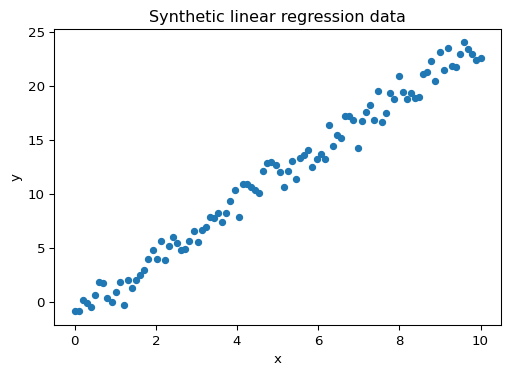

In [37]:
rng = np.random.default_rng(0)

n = 100
x = np.linspace(0.0, 10.0, n)
noise = rng.normal(0.0, 1.0, size=n)
y = 2.5 * x - 1.0 + noise

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=20)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic linear regression data")
plt.show()

## 6.5 A synthetic classification dataset

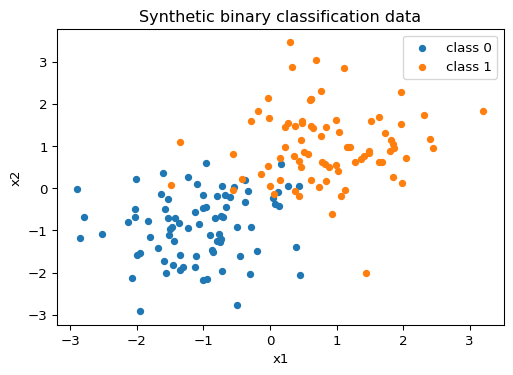

In [38]:
rng = np.random.default_rng(0)

n0 = 80
n1 = 80

X0 = rng.normal(loc=[-1.0, -1.0], scale=0.8, size=(n0, 2))
X1 = rng.normal(loc=[1.0, 1.0], scale=0.8, size=(n1, 2))

X = np.vstack([X0, X1])
y = np.concatenate([np.zeros(n0), np.ones(n1)])

plt.figure(figsize=(6, 4))
plt.scatter(X0[:, 0], X0[:, 1], label="class 0", s=20)
plt.scatter(X1[:, 0], X1[:, 1], label="class 1", s=20)
plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic binary classification data")
plt.show()

## 6.6 Train-test splitting by permutation

In [39]:
rng = np.random.default_rng(7)
n = len(X)
perm = rng.permutation(n)

train_size = int(0.8 * n)
train_idx = perm[:train_size]
test_idx = perm[train_size:]

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print("X_train.shape =", X_train.shape)
print("X_test.shape =", X_test.shape)

X_train.shape = (128, 2)
X_test.shape = (32, 2)

## 6.7 Exercises

1.  Generate a random vector with a fixed seed and verify
    reproducibility.
2.  Create a synthetic regression dataset with noise.
3.  Create a synthetic binary classification dataset in two dimensions.
4.  Split a dataset into train and test subsets using a permutation.
5.  Explain why fixed seeds are useful in teaching and experimentation.

## 6.8 Worked example

In [40]:
rng = np.random.default_rng(2024)

X = rng.normal(size=(12, 3))
y = (X[:, 0] - X[:, 1] > 0).astype(int)

perm = rng.permutation(len(X))
split = 8

X_train = X[perm[:split]]
X_test = X[perm[split:]]
y_train = y[perm[:split]]
y_test = y[perm[split:]]

print("y_train =", y_train)
print("y_test =", y_test)

y_train = [1 0 1 1 1 0 0 0]
y_test = [0 1 0 1]

# 7. pandas as a Data Interface

## 7.1 Why pandas belongs after NumPy

For mathematically trained students it is usually more effective to
learn NumPy first. Once arrays, shapes, and matrix operations are
conceptually clear, pandas can be introduced as an interface for
real-world tabular data.

The key pedagogical message is:

> **pandas handles labeled tabular data; NumPy performs the mathematical
> core.**

## 7.2 A small example DataFrame

In [41]:
df = pd.DataFrame({
    "age": [22, 27, 31, 45, 38, 29],
    "income": [42000, 51000, 64000, 83000, 72000, 56000],
    "hours_studied": [10, 12, 7, 4, 6, 9],
    "passed": [1, 1, 0, 0, 1, 1]
})

df

A DataFrame can be viewed as a matrix together with labels and
heterogeneous metadata.

## 7.3 Selecting columns and rows

In [42]:
print(df["age"])
print()
print(df[["age", "income"]])
print()
print(df.iloc[0])
print()
print(df.loc[0:2, ["age", "passed"]])

0    22
1    27
2    31
3    45
4    38
5    29
Name: age, dtype: int64

   age  income
0   22   42000
1   27   51000
2   31   64000
3   45   83000
4   38   72000
5   29   56000

age                 22
income           42000
hours_studied       10
passed               1
Name: 0, dtype: int64

   age  passed
0   22       1
1   27       1
2   31       0

## 7.4 Filtering rows

In [43]:
filtered = df[df["income"] > 55000]
filtered

## 7.5 Missing values

In [44]:
df_missing = df.copy()
df_missing.loc[2, "income"] = np.nan
df_missing.loc[4, "hours_studied"] = np.nan

print(df_missing)
print()
print(df_missing.isna())
print()
print(df_missing.dropna())

   age   income  hours_studied  passed
0   22  42000.0           10.0       1
1   27  51000.0           12.0       1
2   31      NaN            7.0       0
3   45  83000.0            4.0       0
4   38  72000.0            NaN       1
5   29  56000.0            9.0       1

     age  income  hours_studied  passed
0  False   False          False   False
1  False   False          False   False
2  False    True          False   False
3  False   False          False   False
4  False   False           True   False
5  False   False          False   False

   age   income  hours_studied  passed
0   22  42000.0           10.0       1
1   27  51000.0           12.0       1
3   45  83000.0            4.0       0
5   29  56000.0            9.0       1

## 7.6 From pandas to NumPy

This is the crucial transition.

In [45]:
clean = df_missing.dropna()

X = clean[["age", "income", "hours_studied"]].to_numpy(dtype=float)
y = clean["passed"].to_numpy(dtype=float)

print("X =")
print(X)
print()
print("y =", y)
print("X.shape =", X.shape)
print("y.shape =", y.shape)

X =
[[2.2e+01 4.2e+04 1.0e+01]
 [2.7e+01 5.1e+04 1.2e+01]
 [4.5e+01 8.3e+04 4.0e+00]
 [2.9e+01 5.6e+04 9.0e+00]]

y = [1. 1. 0. 1.]
X.shape = (4, 3)
y.shape = (4,)

Once we reach `X` and `y`, we are back in the mathematical world of
arrays.

## 7.7 Reading a CSV file

The next cell assumes that a file named `ml_dataset.csv` is available in
the same directory. If that file is not present, the fallback code
creates a simple example dataset instead.

In [46]:
from pathlib import Path

csv_path = Path("ml_dataset.csv")

if csv_path.exists():
    df_csv = pd.read_csv(csv_path)
else:
    rng = np.random.default_rng(42)
    n = 120
    df_csv = pd.DataFrame({
        "age": rng.integers(18, 65, size=n),
        "income": rng.normal(55000, 14000, size=n),
        "hours_studied": rng.normal(8, 2, size=n),
    })
    logits = (
        -4
        + 0.00005 * df_csv["income"]
        + 0.25 * df_csv["hours_studied"]
        - 0.02 * df_csv["age"]
    )
    probs = 1 / (1 + np.exp(-logits))
    df_csv["target"] = (rng.random(n) < probs).astype(int)

df_csv.head()

## 7.8 Basic exploratory analysis

In [47]:
print(df_csv.describe())
print()
print(df_csv.dtypes)

             age        income  hours_studied      target
count  120.00000    120.000000     120.000000  120.000000
mean    41.95000  53343.380771       7.991499    0.458333
std     12.83499  12735.834218       2.016080    0.500350
min     18.00000  25151.352070       2.866683    0.000000
25%     31.00000  43345.030963       6.670809    0.000000
50%     42.00000  52550.425867       7.808451    0.000000
75%     54.00000  61287.290680       8.879359    1.000000
max     63.00000  95794.074524      13.810134    1.000000

age                int64
income           float64
hours_studied    float64
target             int64
dtype: object

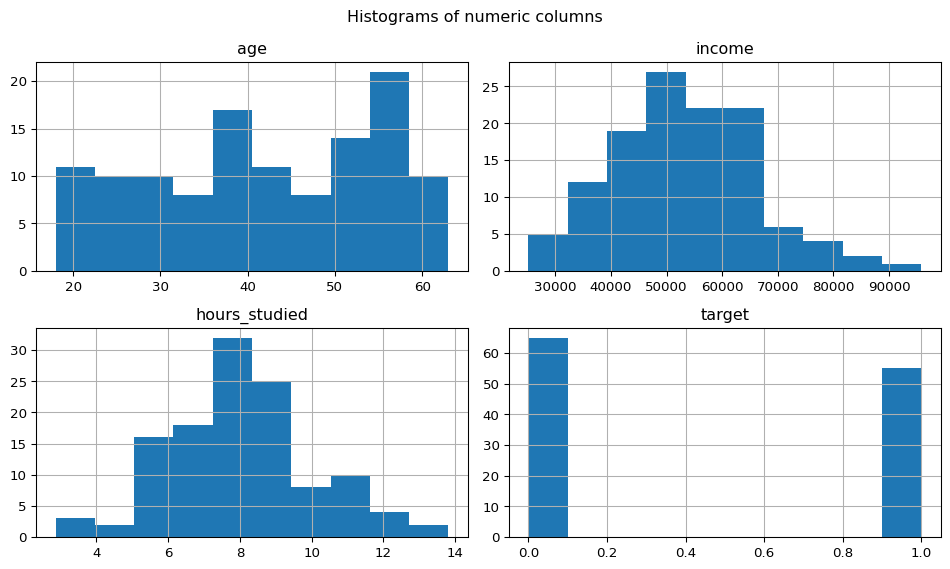

In [48]:
numeric_cols = [c for c in df_csv.columns if pd.api.types.is_numeric_dtype(df_csv[c])]
df_csv[numeric_cols].hist(figsize=(10, 6))
plt.suptitle("Histograms of numeric columns")
plt.tight_layout()
plt.show()

## 7.9 Exercises

1.  Create a DataFrame with at least three columns and six rows.
2.  Select two columns and convert them to a NumPy array.
3.  Introduce missing values and remove them.
4.  Filter a DataFrame by a threshold condition.
5.  Explain the sentence “pandas is the interface, NumPy is the engine.”

## 7.10 Worked example

In [49]:
df_small = pd.DataFrame({
    "feature_1": [1.0, 2.0, 3.0, 4.0],
    "feature_2": [10.0, 20.0, 30.0, 40.0],
    "label": [0, 1, 0, 1]
})

X = df_small[["feature_1", "feature_2"]].to_numpy()
y = df_small["label"].to_numpy()

print("X =")
print(X)
print("y =", y)

X =
[[ 1. 10.]
 [ 2. 20.]
 [ 3. 30.]
 [ 4. 40.]]
y = [0 1 0 1]

# 8. Linear Regression from First Principles

## 8.1 Problem statement

Suppose we are given data

$$(x_i, y_i) \in \mathbb{R}^d \times \mathbb{R},
\quad i = 1, \dots, n.$$

We collect the inputs as rows of a matrix

$$X \in \mathbb{R}^{n \times d}$$

and the outputs as a vector

$$y \in \mathbb{R}^n.$$

A linear model predicts

$$\hat y = Xw.$$

The least squares objective is

$$f(w) = \|Xw - y\|_2^2.$$

Our goal is to find

$$w^\ast = \arg\min_{w \in \mathbb{R}^d} \|Xw - y\|_2^2.$$

## 8.2 Derivation of the normal equation

Expanding the square gives

$$f(w) = (Xw - y)^\top (Xw - y).$$

Differentiating with respect to $w$ yields

$$\nabla f(w) = 2X^\top(Xw - y).$$

At a critical point we therefore require

$$X^\top(Xw - y) = 0,$$

hence

$$X^\top X w = X^\top y.$$

This is the **normal equation**.

If $X^\top X$ is invertible, the minimizer is

$$w^\ast = (X^\top X)^{-1} X^\top y.$$

Computationally, we prefer the solve form

$$w^\ast = \mathrm{solve}(X^\top X,\; X^\top y).$$

## 8.3 A small one-dimensional example

In [50]:
X_raw = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([1.8, 2.9, 3.7, 5.1, 5.9])

X = np.column_stack([np.ones(len(X_raw)), X_raw])

print("X =")
print(X)
print("y =", y)

X =
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]
y = [1.8 2.9 3.7 5.1 5.9]

The first column of ones corresponds to the intercept term.

## 8.4 Solving the normal equation

In [51]:
w = np.linalg.solve(X.T @ X, X.T @ y)
print("w =", w)

w = [0.76 1.04]

## 8.5 Predictions and residuals

In [52]:
y_pred = X @ w
residuals = y - y_pred

print("predictions =", y_pred)
print("residuals =", residuals)
print("MSE =", np.mean(residuals**2))

predictions = [1.8  2.84 3.88 4.92 5.96]
residuals = [ 2.44249065e-15  6.00000000e-02 -1.80000000e-01  1.80000000e-01
 -6.00000000e-02]
MSE = 0.014399999999999963

## 8.6 Visualization

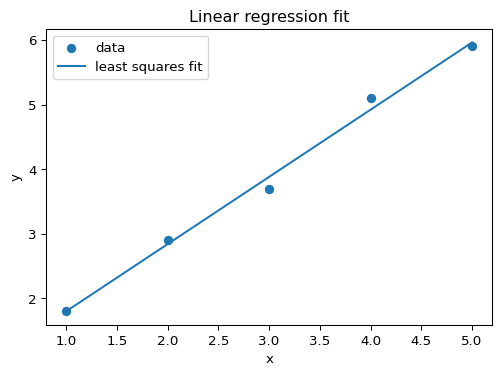

In [53]:
plt.figure(figsize=(6, 4))
plt.scatter(X_raw, y, label="data")
plt.plot(X_raw, y_pred, label="least squares fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Linear regression fit")
plt.show()

## 8.7 Geometric interpretation

The normal equation

$$X^\top(Xw^\ast - y)=0$$

says that the residual vector $r = y - Xw^\ast$ is orthogonal to the
column space of $X$. Thus $Xw^\ast$ is the orthogonal projection of $y$
onto the column space of $X$.

This is one of the deepest conceptual points in the course. Least
squares is not merely an algorithm; it is an orthogonal projection
problem.

## 8.8 A synthetic multi-feature example

In [54]:
rng = np.random.default_rng(0)

n = 200
d = 3

X_features = rng.normal(size=(n, d))
true_w = np.array([1.5, -2.0, 0.75])
noise = 0.3 * rng.standard_normal(n)
y = X_features @ true_w + noise

X = X_features
w_hat = np.linalg.solve(X.T @ X, X.T @ y)

print("true_w =", true_w)
print("w_hat  =", w_hat)
print("estimation error =", np.linalg.norm(w_hat - true_w))

true_w = [ 1.5  -2.    0.75]
w_hat  = [ 1.47371393 -2.02925259  0.76647239]
estimation error = 0.04263814767727305

## 8.9 Regression with an explicit intercept

In [55]:
X_aug = np.column_stack([np.ones(n), X_features])
w_aug = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)

print("w_aug =", w_aug)

w_aug = [-0.01084165  1.47300522 -2.02884578  0.76590767]

The first component is the intercept.

## 8.10 Exercises

1.  Derive the normal equation carefully starting from
    $f(w)=\|Xw-y\|_2^2$.
2.  Implement least squares on a small one-dimensional dataset.
3.  Add noise to the outputs and observe how the solution changes.
4.  Compare the true coefficient vector to the estimated one on
    synthetic data.
5.  Explain the projection interpretation in your own words.

## 8.11 Worked solution example

estimated parameters = [1.11582782 2.73530772]
MSE = 0.20363506927607578

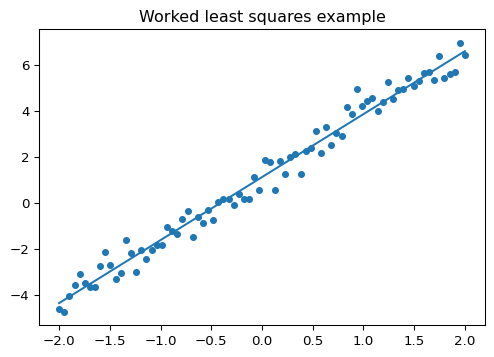

In [56]:
rng = np.random.default_rng(5)

n = 80
x = np.linspace(-2, 2, n)
y = 1.2 + 2.7 * x + 0.5 * rng.standard_normal(n)

X = np.column_stack([np.ones(n), x])
w = np.linalg.solve(X.T @ X, X.T @ y)
y_pred = X @ w

print("estimated parameters =", w)
print("MSE =", np.mean((y - y_pred)**2))

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=18)
plt.plot(x, y_pred)
plt.title("Worked least squares example")
plt.show()

# 9. Gradient Descent for Least Squares

## 9.1 Why gradient descent?

The normal equation is elegant, but direct linear solves are not the
only way to optimize an objective. Machine learning often relies on
iterative optimization.

For least squares we consider the empirical risk

$$f(w) = \frac{1}{n}\|Xw - y\|_2^2.$$

Its gradient is

$$\nabla f(w) = \frac{2}{n}X^\top(Xw - y).$$

The gradient descent iteration is

$$w_{k+1} = w_k - \eta \nabla f(w_k),$$

where $\eta > 0$ is the learning rate.

## 9.2 Implementation

In [57]:
rng = np.random.default_rng(0)

n = 120
d = 2
X = rng.normal(size=(n, d))
true_w = np.array([2.0, -1.0])
y = X @ true_w + 0.2 * rng.standard_normal(n)

w = np.zeros(d)
eta = 0.1
num_steps = 200

loss_history = []

for _ in range(num_steps):
    grad = (2 / n) * X.T @ (X @ w - y)
    w = w - eta * grad
    loss = np.mean((X @ w - y)**2)
    loss_history.append(loss)

print("estimated w =", w)
print("true_w =", true_w)
print("final loss =", loss_history[-1])

estimated w = [ 1.99927294 -1.03094039]
true_w = [ 2. -1.]
final loss = 0.039563151213584634

## 9.3 Convergence plot

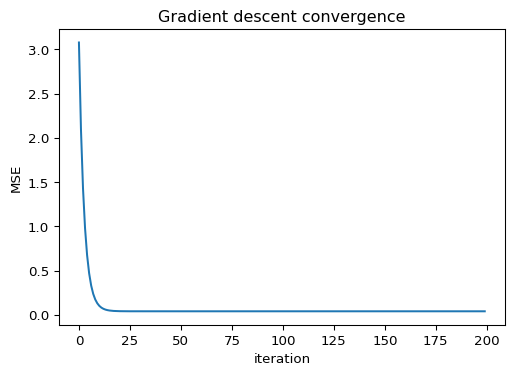

In [58]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title("Gradient descent convergence")
plt.show()

## 9.4 Comparison with closed-form least squares

In [59]:
w_closed = np.linalg.solve(X.T @ X, X.T @ y)

print("w_closed =", w_closed)
print("w_gd     =", w)
print("difference =", np.linalg.norm(w_closed - w))

w_closed = [ 1.99927294 -1.03094039]
w_gd     = [ 1.99927294 -1.03094039]
difference = 1.2947314098277875e-15

## 9.5 Learning rate effects

The choice of learning rate matters.

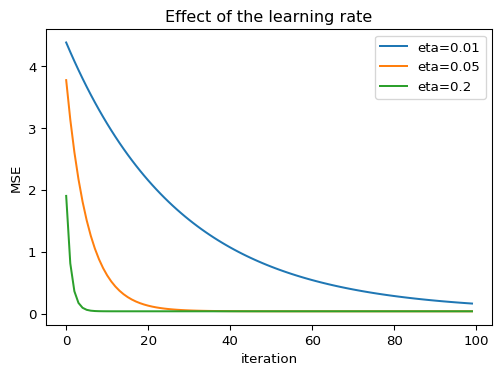

In [60]:
etas = [0.01, 0.05, 0.2]
histories = []

for eta in etas:
    w_eta = np.zeros(d)
    hist = []
    for _ in range(100):
        grad = (2 / n) * X.T @ (X @ w_eta - y)
        w_eta -= eta * grad
        hist.append(np.mean((X @ w_eta - y)**2))
    histories.append(hist)

plt.figure(figsize=(6, 4))
for eta, hist in zip(etas, histories):
    plt.plot(hist, label=f"eta={eta}")
plt.legend()
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title("Effect of the learning rate")
plt.show()

## 9.6 Gradient checking idea

A very useful debugging principle is to compare an analytic gradient
with a finite-difference approximation.

For a scalar function $f:\mathbb{R}^d \to \mathbb{R}$ and a small
perturbation $h$, one can compare

$$\frac{f(w + h e_j) - f(w - h e_j)}{2h}$$

to the $j$-th component of the analytic gradient.

In [61]:
def least_squares_loss(w, X, y):
    return np.mean((X @ w - y)**2)

def least_squares_grad(w, X, y):
    n = len(y)
    return (2 / n) * X.T @ (X @ w - y)

w0 = np.array([0.3, -0.2])
g = least_squares_grad(w0, X, y)

h = 1e-6
g_fd = np.zeros_like(w0)
for j in range(len(w0)):
    e = np.zeros_like(w0)
    e[j] = 1.0
    g_fd[j] = (
        least_squares_loss(w0 + h * e, X, y)
        - least_squares_loss(w0 - h * e, X, y)
    ) / (2 * h)

print("analytic grad =", g)
print("finite diff grad =", g_fd)
print("difference =", np.linalg.norm(g - g_fd))

analytic grad = [-3.12182606  1.2955987 ]
finite diff grad = [-3.12182606  1.2955987 ]
difference = 1.923325663960519e-10

## 9.7 Exercises

1.  Derive the gradient of the least squares loss.
2.  Implement gradient descent for a synthetic regression problem.
3.  Compare the result to the normal equation solution.
4.  Experiment with too-small and too-large learning rates.
5.  Use a finite-difference test to validate your gradient formula.

## 9.8 Worked example

w_true = [ 1.  -1.5  0.5]
w = [ 0.9990376  -1.49071693  0.49701198]

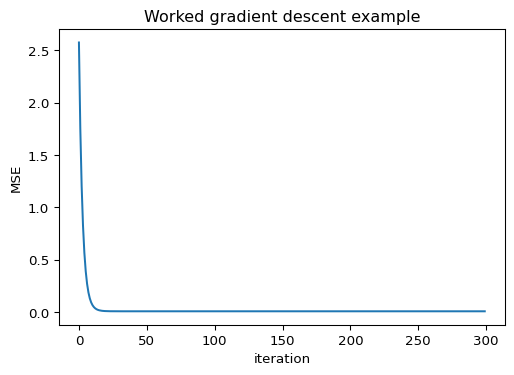

In [62]:
rng = np.random.default_rng(11)

n = 150
d = 3
X = rng.normal(size=(n, d))
w_true = np.array([1.0, -1.5, 0.5])
y = X @ w_true + 0.1 * rng.normal(size=n)

w = np.zeros(d)
eta = 0.08
losses = []

for _ in range(300):
    grad = (2 / n) * X.T @ (X @ w - y)
    w -= eta * grad
    losses.append(np.mean((X @ w - y)**2))

print("w_true =", w_true)
print("w =", w)

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Worked gradient descent example")
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.show()

# 10. Binary Classification and Logistic Regression

## 10.1 Why linear regression is not enough for classification

If the target values are $0$ and $1$, then least squares can still be
used, but it does not model probabilities naturally and can produce
values outside the interval $[0,1]$.

To model probabilities we use the sigmoid function

$$\sigma(t) = \frac{1}{1 + e^{-t}}.$$

## 10.2 The sigmoid function

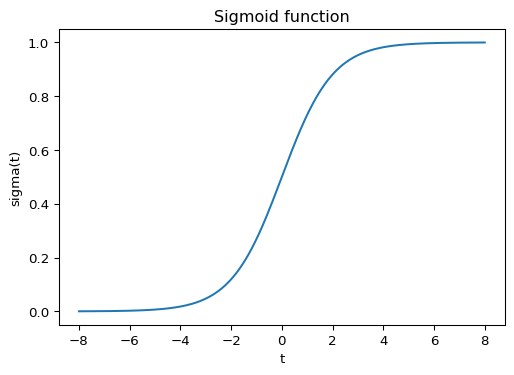

In [63]:
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

t = np.linspace(-8, 8, 400)

plt.figure(figsize=(6, 4))
plt.plot(t, sigmoid(t))
plt.xlabel("t")
plt.ylabel("sigma(t)")
plt.title("Sigmoid function")
plt.show()

## 10.3 Logistic model

Given $x \in \mathbb{R}^d$ and parameter vector $w \in \mathbb{R}^d$,
the logistic model is

$$p(y=1 \mid x) = \sigma(x^\top w).$$

For a full dataset with design matrix $X$, the vector of predicted
probabilities is

$$p = \sigma(Xw),$$

where the sigmoid is applied componentwise.

## 10.4 Binary cross-entropy loss

If $y_i \in \{0,1\}$ and $p_i$ is the predicted probability of class
$1$, the average logistic loss is

$$L(w) = -\frac{1}{n}\sum_{i=1}^n \left(
y_i \log p_i + (1-y_i)\log(1-p_i)
\right).$$

This is also called binary cross-entropy.

## 10.5 Gradient of the logistic loss

A standard calculation shows that

$$\nabla L(w) = \frac{1}{n} X^\top (p - y),$$

where

$$p = \sigma(Xw).$$

This compact formula is one of the main reasons logistic regression is
such an elegant teaching example.

## 10.6 Synthetic dataset

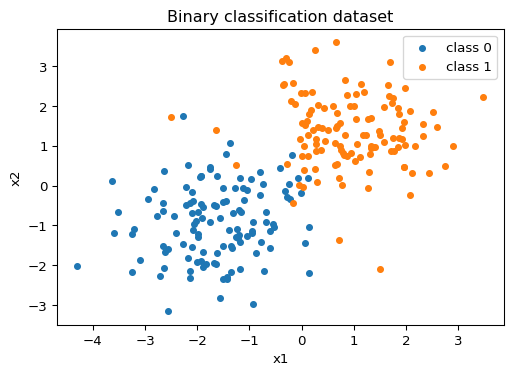

In [64]:
rng = np.random.default_rng(0)

n0 = 120
n1 = 120

X0 = rng.normal(loc=[-1.5, -1.0], scale=0.9, size=(n0, 2))
X1 = rng.normal(loc=[1.0, 1.3], scale=0.9, size=(n1, 2))

X_raw = np.vstack([X0, X1])
y = np.concatenate([np.zeros(n0), np.ones(n1)])

plt.figure(figsize=(6, 4))
plt.scatter(X0[:, 0], X0[:, 1], s=18, label="class 0")
plt.scatter(X1[:, 0], X1[:, 1], s=18, label="class 1")
plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Binary classification dataset")
plt.show()

## 10.7 Add the intercept column

In [65]:
X = np.column_stack([np.ones(len(X_raw)), X_raw])
print("X.shape =", X.shape)
print("y.shape =", y.shape)

X.shape = (240, 3)
y.shape = (240,)

## 10.8 Binary cross-entropy implementation

In [66]:
def binary_cross_entropy(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_prob)
        + (1 - y_true) * np.log(1 - y_prob)
    )

## 10.9 Gradient descent for logistic regression

In [67]:
n, d = X.shape
w = np.zeros(d)
eta = 0.2
num_steps = 1000

history = []

for _ in range(num_steps):
    p = sigmoid(X @ w)
    grad = (X.T @ (p - y)) / n
    w -= eta * grad
    history.append(binary_cross_entropy(y, p))

print("w =", w)
print("final loss =", history[-1])

w = [0.40651878 2.72978342 2.35158575]
final loss = 0.09141766952958857

## 10.10 Loss curve

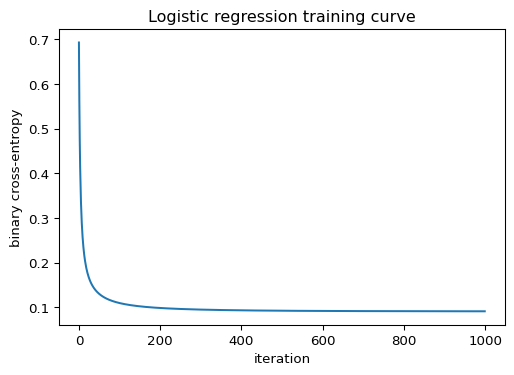

In [68]:
plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("binary cross-entropy")
plt.title("Logistic regression training curve")
plt.show()

## 10.11 Classification accuracy

In [69]:
p = sigmoid(X @ w)
y_pred = (p >= 0.5).astype(int)

accuracy = np.mean(y_pred == y)
print("accuracy =", accuracy)

accuracy = 0.9583333333333334

## 10.12 Decision boundary visualization

For a model

$$p(y=1 \mid x) = \sigma(w_0 + w_1 x_1 + w_2 x_2),$$

the decision boundary at threshold $0.5$ is

$$w_0 + w_1 x_1 + w_2 x_2 = 0.$$

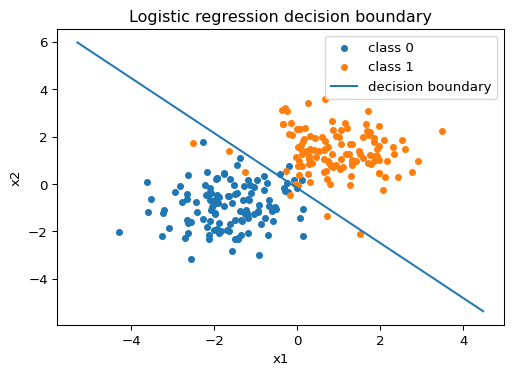

In [70]:
plt.figure(figsize=(6, 4))
plt.scatter(X0[:, 0], X0[:, 1], s=18, label="class 0")
plt.scatter(X1[:, 0], X1[:, 1], s=18, label="class 1")

x1_min, x1_max = X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1
grid_x1 = np.linspace(x1_min, x1_max, 200)

if abs(w[2]) > 1e-12:
    grid_x2 = -(w[0] + w[1] * grid_x1) / w[2]
    plt.plot(grid_x1, grid_x2, label="decision boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Logistic regression decision boundary")
plt.show()

## 10.13 Confusion counts

In [71]:
tp = np.sum((y_pred == 1) & (y == 1))
tn = np.sum((y_pred == 0) & (y == 0))
fp = np.sum((y_pred == 1) & (y == 0))
fn = np.sum((y_pred == 0) & (y == 1))

print("TP =", tp)
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)

TP = 114
TN = 116
FP = 4
FN = 6

## 10.14 Exercises

1.  Derive the logistic regression gradient formula.
2.  Train logistic regression on a synthetic 2D dataset.
3.  Plot the decision boundary.
4.  Compute the accuracy and confusion counts.
5.  Explain why clipping probabilities is useful in the cross-entropy
    implementation.

## 10.15 Worked example

true_w = [-0.5  2.  -1.2]
estimated_w = [-0.36513097  1.69627472 -1.06355111]
accuracy = 0.78

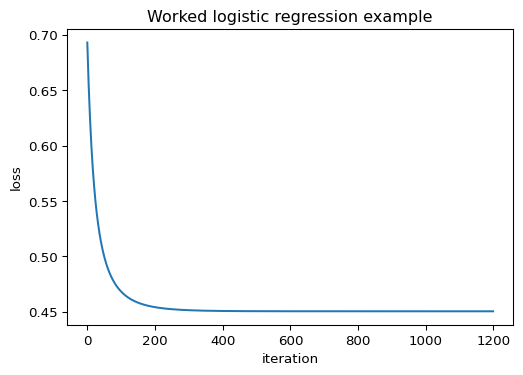

In [72]:
rng = np.random.default_rng(17)

n = 200
X_raw = rng.normal(size=(n, 2))
true_w = np.array([-0.5, 2.0, -1.2])

X = np.column_stack([np.ones(n), X_raw])
p_true = sigmoid(X @ true_w)
y = (rng.random(n) < p_true).astype(float)

w = np.zeros(X.shape[1])
eta = 0.1
losses = []

for _ in range(1200):
    p = sigmoid(X @ w)
    grad = X.T @ (p - y) / n
    w -= eta * grad
    losses.append(binary_cross_entropy(y, p))

print("true_w =", true_w)
print("estimated_w =", w)
print("accuracy =", np.mean((sigmoid(X @ w) >= 0.5) == y))

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Worked logistic regression example")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.show()

# 11. Data Preprocessing, Features, and Shapes

## 11.1 Why preprocessing matters

A model is not only determined by its optimization method. The
representation of the data matters.

Common preprocessing tasks include:

- selecting relevant columns;
- handling missing values;
- encoding categorical information;
- centering and scaling;
- constructing interaction features;
- splitting data into training and testing sets.

## 11.2 Reshape, flatten, and new axes

In [73]:
x = np.arange(12)
X = x.reshape(3, 4)

print("x =", x)
print("X =")
print(X)
print("x.shape =", x.shape)
print("X.shape =", X.shape)
print("flatten =", X.flatten())
print("ravel   =", X.ravel())
print("x[:, None].shape =", np.array([1, 2, 3])[:, None].shape)

x = [ 0  1  2  3  4  5  6  7  8  9 10 11]
X =
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
x.shape = (12,)
X.shape = (3, 4)
flatten = [ 0  1  2  3  4  5  6  7  8  9 10 11]
ravel   = [ 0  1  2  3  4  5  6  7  8  9 10 11]
x[:, None].shape = (3, 1)

## 11.3 Feature scaling

In [74]:
rng = np.random.default_rng(9)

X = np.column_stack([
    rng.normal(0, 1, size=200),
    rng.normal(1000, 250, size=200),
    rng.normal(0.01, 0.003, size=200)
])

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
Z = (X - mu) / sigma

print("original feature scales:")
print(np.std(X, axis=0))
print("scaled feature scales:")
print(np.std(Z, axis=0))

original feature scales:
[1.02119562e+00 2.42888357e+02 3.16507367e-03]
scaled feature scales:
[1. 1. 1.]

Scaling is often crucial for gradient-based optimization because poorly
scaled features can slow convergence.

## 11.4 Train-test split using pandas

In [75]:
df = df_csv.copy()

numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
target_col = "target" if "target" in df.columns else numeric_cols[-1]
feature_cols = [c for c in numeric_cols if c != target_col]

df_model = df[feature_cols + [target_col]].dropna()

X = df_model[feature_cols].to_numpy(dtype=float)
y = df_model[target_col].to_numpy(dtype=float)

rng = np.random.default_rng(123)
perm = rng.permutation(len(X))
split = int(0.8 * len(X))

X_train = X[perm[:split]]
X_test = X[perm[split:]]
y_train = y[perm[:split]]
y_test = y[perm[split:]]

print("feature columns =", feature_cols)
print("X_train.shape =", X_train.shape)
print("X_test.shape =", X_test.shape)

feature columns = ['age', 'income', 'hours_studied']
X_train.shape = (96, 3)
X_test.shape = (24, 3)

## 11.5 Polynomial features in one variable

A linear model becomes nonlinear in the original input if we augment the
feature map.

For one variable $x$, define

$$\phi(x) = (1, x, x^2, x^3).$$

Then the model

$$\hat y = w_0 + w_1 x + w_2 x^2 + w_3 x^3$$

is still linear in the parameter vector $w$.

In [76]:
x = np.linspace(-2, 2, 100)
Phi = np.column_stack([np.ones_like(x), x, x**2, x**3])

print("Phi.shape =", Phi.shape)
print(Phi[:5])

Phi.shape = (100, 4)
[[ 1.         -2.          4.         -8.        ]
 [ 1.         -1.95959596  3.84001632 -7.52488047]
 [ 1.         -1.91919192  3.68329762 -7.06895503]
 [ 1.         -1.87878788  3.52984389 -6.63182792]
 [ 1.         -1.83838384  3.37965514 -6.21310338]]

## 11.6 A polynomial regression example

estimated coefficients = [ 1.11483741 -1.11943614  1.95232421 -0.45054691]

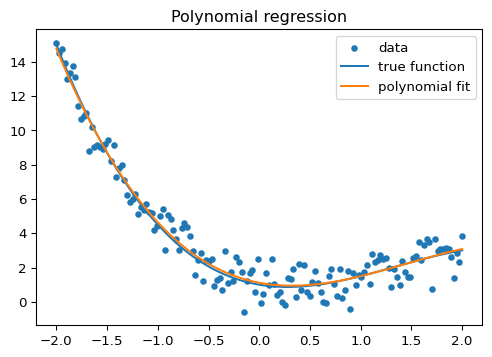

In [77]:
rng = np.random.default_rng(0)

x = np.linspace(-2, 2, 150)
y_true = 1 - x + 2 * x**2 - 0.5 * x**3
y = y_true + 0.8 * rng.standard_normal(len(x))

Phi = np.column_stack([np.ones_like(x), x, x**2, x**3])
w = np.linalg.solve(Phi.T @ Phi, Phi.T @ y)
y_pred = Phi @ w

print("estimated coefficients =", w)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=15, label="data")
plt.plot(x, y_true, label="true function")
plt.plot(x, y_pred, label="polynomial fit")
plt.legend()
plt.title("Polynomial regression")
plt.show()

## 11.7 Exercises

1.  Explain the difference between `reshape`, `flatten`, and `ravel`.
2.  Standardize a feature matrix and verify columnwise mean $0$ and
    standard deviation $1$.
3.  Build polynomial features up to degree $3$ for a one-dimensional
    dataset.
4.  Split a dataset into train and test parts.
5.  Explain why feature engineering can make a linear model nonlinear in
    the original input.

## 11.8 Worked example

In [78]:
x = np.linspace(-1, 1, 8)
Phi = np.column_stack([np.ones_like(x), x, x**2])
print("Phi =")
print(Phi)

mu = np.mean(Phi[:, 1:], axis=0)
sigma = np.std(Phi[:, 1:], axis=0)
Phi_scaled = Phi.copy()
Phi_scaled[:, 1:] = (Phi_scaled[:, 1:] - mu) / sigma

print()
print("Phi_scaled =")
print(Phi_scaled)

Phi =
[[ 1.         -1.          1.        ]
 [ 1.         -0.71428571  0.51020408]
 [ 1.         -0.42857143  0.18367347]
 [ 1.         -0.14285714  0.02040816]
 [ 1.          0.14285714  0.02040816]
 [ 1.          0.42857143  0.18367347]
 [ 1.          0.71428571  0.51020408]
 [ 1.          1.          1.        ]]

Phi_scaled =
[[ 1.         -1.52752523  1.52752523]
 [ 1.         -1.09108945  0.21821789]
 [ 1.         -0.65465367 -0.65465367]
 [ 1.         -0.21821789 -1.09108945]
 [ 1.          0.21821789 -1.09108945]
 [ 1.          0.65465367 -0.65465367]
 [ 1.          1.09108945  0.21821789]
 [ 1.          1.52752523  1.52752523]]

# 12. Regularization and Overfitting

## 12.1 Motivation

When a model is too flexible relative to the amount of data, it may fit
noise rather than structure. This phenomenon is called overfitting.

One way to control complexity is regularization.

## 12.2 Ridge regression

The ridge objective is

$$f_\lambda(w) = \|Xw - y\|_2^2 + \lambda \|w\|_2^2$$

for $\lambda > 0$.

Differentiating gives

$$\nabla f_\lambda(w) = 2X^\top(Xw - y) + 2\lambda w.$$

The normal equation becomes

$$(X^\top X + \lambda I)w = X^\top y.$$

## 12.3 Ridge implementation

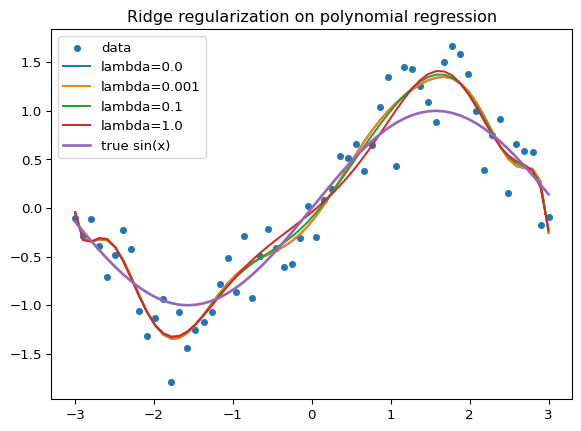

In [79]:
rng = np.random.default_rng(0)

n = 60
x = np.linspace(-3, 3, n)
y_true = np.sin(x)
y = y_true + 0.35 * rng.standard_normal(n)

degree = 12
Phi = np.column_stack([x**k for k in range(degree + 1)])

lam_values = [0.0, 1e-3, 1e-1, 1.0]

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=18, label="data")

for lam in lam_values:
    A = Phi.T @ Phi + lam * np.eye(Phi.shape[1])
    w = np.linalg.solve(A, Phi.T @ y)
    y_pred = Phi @ w
    plt.plot(x, y_pred, label=f"lambda={lam}")

plt.plot(x, y_true, label="true sin(x)", linewidth=2)
plt.legend()
plt.title("Ridge regularization on polynomial regression")
plt.show()

## 12.4 Train-test perspective

A model can have very small training error and much worse test error.
That discrepancy is a practical sign of overfitting.

In [80]:
rng = np.random.default_rng(1)

perm = rng.permutation(n)
split = int(0.7 * n)
train_idx = perm[:split]
test_idx = perm[split:]

x_train = x[train_idx]
y_train = y[train_idx]
x_test = x[test_idx]
y_test = y[test_idx]

Phi_train = np.column_stack([x_train**k for k in range(degree + 1)])
Phi_test = np.column_stack([x_test**k for k in range(degree + 1)])

for lam in [0.0, 1e-3, 1e-2, 1e-1, 1.0]:
    A = Phi_train.T @ Phi_train + lam * np.eye(Phi_train.shape[1])
    w = np.linalg.solve(A, Phi_train.T @ y_train)
    train_mse = np.mean((Phi_train @ w - y_train)**2)
    test_mse = np.mean((Phi_test @ w - y_test)**2)
    print(f"lambda={lam:>5}: train_mse={train_mse:.4f}, test_mse={test_mse:.4f}")

lambda=  0.0: train_mse=0.0551, test_mse=0.1117
lambda=0.001: train_mse=0.0551, test_mse=0.1116
lambda= 0.01: train_mse=0.0551, test_mse=0.1113
lambda=  0.1: train_mse=0.0563, test_mse=0.1108
lambda=  1.0: train_mse=0.0613, test_mse=0.1198

## 12.5 Exercises

1.  Derive the ridge normal equation.
2.  Fit a high-degree polynomial with and without regularization.
3.  Compare train and test errors for different values of $\lambda$.
4.  Explain why ridge can improve generalization.
5.  Discuss whether the intercept should always be regularized in
    practical applications.

## 12.6 Worked example

In [81]:
rng = np.random.default_rng(2)

x = np.linspace(-2, 2, 50)
y = np.cos(2 * x) + 0.2 * rng.normal(size=len(x))
Phi = np.column_stack([x**k for k in range(9)])

for lam in [0.0, 0.01, 0.1]:
    w = np.linalg.solve(Phi.T @ Phi + lam * np.eye(Phi.shape[1]), Phi.T @ y)
    print(f"lambda={lam}, coefficient norm={np.linalg.norm(w):.3f}")

lambda=0.0, coefficient norm=2.505
lambda=0.01, coefficient norm=2.391
lambda=0.1, coefficient norm=1.834

# 13. Mini-Batches and Stochastic Ideas

## 13.1 From full gradients to sampled gradients

For large datasets, computing the full gradient at every step can be
expensive. Instead one can approximate it by sampling a subset of
observations.

This leads to mini-batch gradient methods.

## 13.2 A simple batch sampler

In [82]:
rng = np.random.default_rng(0)

n = 500
d = 4
X = rng.normal(size=(n, d))
w_true = np.array([1.0, -2.0, 0.5, 1.5])
y = X @ w_true + 0.5 * rng.normal(size=n)

def sample_minibatch(X, y, batch_size, rng):
    idx = rng.choice(len(X), size=batch_size, replace=False)
    return X[idx], y[idx]

Xb, yb = sample_minibatch(X, y, batch_size=16, rng=rng)
print("Xb.shape =", Xb.shape)
print("yb.shape =", yb.shape)

Xb.shape = (16, 4)
yb.shape = (16,)

## 13.3 Mini-batch gradient descent for least squares

In [83]:
rng = np.random.default_rng(1)

w = np.zeros(d)
eta = 0.05
batch_size = 32
num_steps = 500

losses = []

for _ in range(num_steps):
    Xb, yb = sample_minibatch(X, y, batch_size=batch_size, rng=rng)
    grad = (2 / len(Xb)) * Xb.T @ (Xb @ w - yb)
    w -= eta * grad
    losses.append(np.mean((X @ w - y)**2))

print("estimated w =", w)
print("true w =", w_true)

estimated w = [ 1.00794574 -2.02964886  0.51013668  1.5059959 ]
true w = [ 1.  -2.   0.5  1.5]

## 13.4 Comparison with full-batch gradient descent

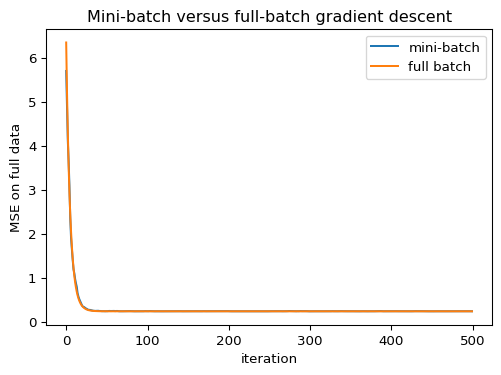

In [84]:
w_full = np.zeros(d)
losses_full = []

for _ in range(num_steps):
    grad_full = (2 / n) * X.T @ (X @ w_full - y)
    w_full -= eta * grad_full
    losses_full.append(np.mean((X @ w_full - y)**2))

plt.figure(figsize=(6, 4))
plt.plot(losses, label="mini-batch")
plt.plot(losses_full, label="full batch")
plt.legend()
plt.xlabel("iteration")
plt.ylabel("MSE on full data")
plt.title("Mini-batch versus full-batch gradient descent")
plt.show()

## 13.5 Exercises

1.  Implement a mini-batch sampler.
2.  Compare mini-batch and full-batch gradient descent on the same
    problem.
3.  Change the batch size and observe the effect on the loss curve.
4.  Explain why mini-batch methods introduce noise into the optimization
    path.
5.  Discuss why stochastic methods are attractive for large-scale
    machine learning.

## 13.6 Worked example

In [85]:
rng = np.random.default_rng(4)

n = 300
d = 2
X = rng.normal(size=(n, d))
w_true = np.array([2.5, -0.7])
y = X @ w_true + 0.3 * rng.normal(size=n)

def mbgd(X, y, batch_size, eta, steps, rng):
    w = np.zeros(X.shape[1])
    hist = []
    for _ in range(steps):
        idx = rng.choice(len(X), size=batch_size, replace=False)
        Xb = X[idx]
        yb = y[idx]
        grad = (2 / batch_size) * Xb.T @ (Xb @ w - yb)
        w -= eta * grad
        hist.append(np.mean((X @ w - y)**2))
    return w, hist

w_mb, hist_mb = mbgd(X, y, batch_size=24, eta=0.08, steps=250, rng=rng)
print("w_mb =", w_mb)

w_mb = [ 2.52243211 -0.67183942]

# 14. A First Neural Network in Pure NumPy

## 14.1 Why neural networks fit naturally into linear algebra

A fully connected neural network is built from repeated compositions of
affine maps and nonlinear activation functions. This makes it an ideal
topic after students are comfortable with matrices, broadcasting, and
vectorization.

We consider a network with one hidden layer:

$$H = \phi(XW_1 + b_1),$$

$$\hat Y = HW_2 + b_2.$$

Here

- $X \in \mathbb{R}^{n \times d}$ is the input matrix;
- $W_1 \in \mathbb{R}^{d \times h}$ is the first weight matrix;
- $b_1 \in \mathbb{R}^{h}$ is the hidden bias;
- $H \in \mathbb{R}^{n \times h}$ is the hidden representation;
- $W_2 \in \mathbb{R}^{h \times m}$ is the second weight matrix;
- $b_2 \in \mathbb{R}^{m}$ is the output bias.

## 14.2 Activation functions

We begin with the ReLU function

$$\mathrm{ReLU}(t) = \max(0, t).$$

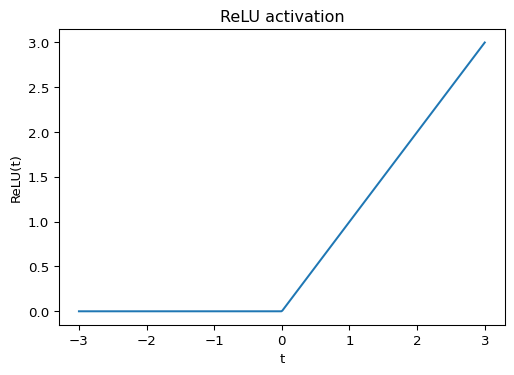

In [86]:
def relu(x):
    return np.maximum(0, x)

t = np.linspace(-3, 3, 400)

plt.figure(figsize=(6, 4))
plt.plot(t, relu(t))
plt.xlabel("t")
plt.ylabel("ReLU(t)")
plt.title("ReLU activation")
plt.show()

## 14.3 Forward pass on XOR-style data

In [87]:
rng = np.random.default_rng(0)

X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = np.array([[0.0], [1.0], [1.0], [0.0]])

d = 2
h = 4
m = 1

W1 = 0.5 * rng.standard_normal((d, h))
b1 = np.zeros(h)
W2 = 0.5 * rng.standard_normal((h, m))
b2 = np.zeros(m)

H = relu(X @ W1 + b1)
Y = H @ W2 + b2

print("H =")
print(H)
print()
print("Y =")
print(Y)

H =
[[0.         0.         0.         0.        ]
 [0.         0.18079753 0.65200002 0.47354048]
 [0.06286511 0.         0.32021133 0.05245006]
 [0.         0.1147451  0.97221135 0.52599054]]

Y =
[[ 0.        ]
 [-0.30779526]
 [-0.12082619]
 [-0.36470917]]

## 14.4 Sigmoid output for binary classification

In [88]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

P = sigmoid(Y)
print("P =")
print(P)

P =
[[0.5       ]
 [0.42365298]
 [0.46983015]
 [0.40982009]]

## 14.5 Binary cross-entropy for network outputs

In [89]:
def bce_from_logits(logits, y_true):
    probs = sigmoid(logits)
    eps = 1e-12
    probs = np.clip(probs, eps, 1 - eps)
    return -np.mean(y_true * np.log(probs) + (1 - y_true) * np.log(1 - probs))

## 14.6 Backpropagation outline

For a first course, it is often enough to outline the structure of
backpropagation without deriving every formula in maximal detail.

Let

$$Z_1 = XW_1 + b_1,
\quad
H = \mathrm{ReLU}(Z_1),
\quad
Z_2 = HW_2 + b_2,
\quad
P = \sigma(Z_2).$$

With binary cross-entropy and sigmoid output, the output error term is

$$\delta_2 = P - y.$$

Then the parameter gradients are

$$\nabla_{W_2} L = \frac{1}{n} H^\top \delta_2,$$

$$\nabla_{b_2} L = \frac{1}{n} \sum_{i=1}^n \delta_{2,i},$$

and for the hidden layer,

$$\delta_1 = (\delta_2 W_2^\top) \odot \mathbf{1}_{Z_1 > 0},$$

$$\nabla_{W_1} L = \frac{1}{n} X^\top \delta_1,
\qquad
\nabla_{b_1} L = \frac{1}{n} \sum_{i=1}^n \delta_1^{(i)}.$$

## 14.7 Training the network

In [90]:
rng = np.random.default_rng(1)

X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = np.array([[0.0], [1.0], [1.0], [0.0]])

d = 2
h = 8
m = 1

W1 = 0.5 * rng.standard_normal((d, h))
b1 = np.zeros(h)
W2 = 0.5 * rng.standard_normal((h, m))
b2 = np.zeros(m)

eta = 0.5
history = []

for _ in range(5000):
    Z1 = X @ W1 + b1
    H = relu(Z1)
    Z2 = H @ W2 + b2
    P = sigmoid(Z2)

    eps = 1e-12
    P_clip = np.clip(P, eps, 1 - eps)
    loss = -np.mean(y * np.log(P_clip) + (1 - y) * np.log(1 - P_clip))
    history.append(loss)

    delta2 = P - y
    dW2 = H.T @ delta2 / len(X)
    db2 = np.mean(delta2, axis=0)

    delta1 = (delta2 @ W2.T) * (Z1 > 0)
    dW1 = X.T @ delta1 / len(X)
    db1 = np.mean(delta1, axis=0)

    W2 -= eta * dW2
    b2 -= eta * db2
    W1 -= eta * dW1
    b1 -= eta * db1

print("final probabilities =")
print(sigmoid(relu(X @ W1 + b1) @ W2 + b2))

final probabilities =
[[3.78893539e-04]
 [9.99833072e-01]
 [9.99838096e-01]
 [1.27758015e-04]]

## 14.8 Training curve

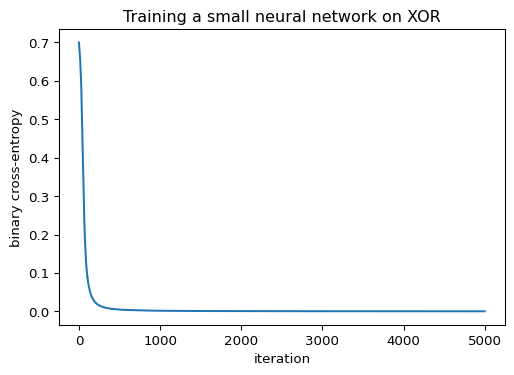

In [91]:
plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("binary cross-entropy")
plt.title("Training a small neural network on XOR")
plt.show()

## 14.9 Exercises

1.  Verify all shapes in the forward pass and backward pass.
2.  Replace ReLU with sigmoid in the hidden layer and compare training
    behavior.
3.  Increase the hidden dimension and observe what changes.
4.  Explain why a linear model cannot solve XOR perfectly.
5.  Derive the gradient formulas for the final layer.

## 14.10 Worked example

In [92]:
rng = np.random.default_rng(3)

X = np.array([
    [-1.0, -1.0],
    [-1.0,  1.0],
    [ 1.0, -1.0],
    [ 1.0,  1.0]
])

y = np.array([[0.0], [1.0], [1.0], [0.0]])

W1 = 0.3 * rng.normal(size=(2, 6))
b1 = np.zeros(6)
W2 = 0.3 * rng.normal(size=(6, 1))
b2 = np.zeros(1)

for _ in range(3000):
    Z1 = X @ W1 + b1
    H = relu(Z1)
    Z2 = H @ W2 + b2
    P = sigmoid(Z2)

    delta2 = P - y
    dW2 = H.T @ delta2 / len(X)
    db2 = np.mean(delta2, axis=0)
    delta1 = (delta2 @ W2.T) * (Z1 > 0)
    dW1 = X.T @ delta1 / len(X)
    db1 = np.mean(delta1, axis=0)

    W2 -= 0.4 * dW2
    b2 -= 0.4 * db2
    W1 -= 0.4 * dW1
    b1 -= 0.4 * db1

print((sigmoid(relu(X @ W1 + b1) @ W2 + b2) > 0.5).astype(int))

[[0]
 [1]
 [1]
 [0]]

# 15. Numerical Stability and Debugging

## 15.1 Why numerical stability matters

Even if a mathematical formula is correct, a direct implementation can
fail because of floating-point limitations. In machine learning, common
issues include:

- overflow in exponentials;
- underflow in probabilities;
- division by very small values;
- catastrophic cancellation;
- exploding or vanishing gradients;
- accidental shape mismatches.

## 15.2 Stable softmax

The naive softmax is

$$\mathrm{softmax}(x)_i = \frac{e^{x_i}}{\sum_j e^{x_j}}.$$

This can overflow when the entries of $x$ are large.

A standard remedy is to subtract the maximum entry first.

In [93]:
def softmax_naive(x):
    ex = np.exp(x)
    return ex / np.sum(ex)

def softmax_stable(x):
    z = x - np.max(x)
    ez = np.exp(z)
    return ez / np.sum(ez)

x = np.array([1000.0, 1001.0, 1002.0])

print("stable softmax =", softmax_stable(x))

stable softmax = [0.09003057 0.24472847 0.66524096]

## 15.3 Stable logistic loss ideas

In practice, probabilities should often be clipped before taking
logarithms.

In [94]:
p = np.array([1e-20, 0.2, 0.8, 1 - 1e-20])
p_clip = np.clip(p, 1e-12, 1 - 1e-12)

print("p =", p)
print("p_clip =", p_clip)
print("log(p_clip) =", np.log(p_clip))

p = [1.e-20 2.e-01 8.e-01 1.e+00]
p_clip = [1.e-12 2.e-01 8.e-01 1.e+00]
log(p_clip) = [-2.76310211e+01 -1.60943791e+00 -2.23143551e-01 -9.99977878e-13]

## 15.4 Shape debugging

When code fails, shapes are often the culprit. Printing shapes
systematically is an underrated debugging method.

In [95]:
X = np.random.randn(5, 3)
w = np.random.randn(3)
b = 0.5

print("X.shape =", X.shape)
print("w.shape =", w.shape)
print("X @ w shape =", (X @ w).shape)
print("(X @ w + b).shape =", (X @ w + b).shape)

X.shape = (5, 3)
w.shape = (3,)
X @ w shape = (5,)
(X @ w + b).shape = (5,)

## 15.5 Gradient checking revisited

Finite differences are a practical way to validate a backpropagation
implementation on small examples.

In [96]:
def f_scalar(w):
    return np.sum(w**2)

def grad_scalar(w):
    return 2 * w

w = np.array([1.5, -2.0, 0.3])
g = grad_scalar(w)

h = 1e-6
g_fd = np.zeros_like(w)

for j in range(len(w)):
    e = np.zeros_like(w)
    e[j] = 1.0
    g_fd[j] = (f_scalar(w + h * e) - f_scalar(w - h * e)) / (2 * h)

print("analytic =", g)
print("finite difference =", g_fd)

analytic = [ 3.  -4.   0.6]
finite difference = [ 3.  -4.   0.6]

## 15.6 Common checklist

When a model behaves strangely, inspect the following.

1.  Are the shapes what you think they are?
2.  Are the dtypes appropriate?
3.  Are the gradients exploding or vanishing?
4.  Is the learning rate too large or too small?
5.  Are you mixing row vectors and column vectors?
6.  Are probabilities clipped before logarithms?
7.  Are features on wildly different scales?

## 15.7 Exercises

1.  Implement naive and stable softmax and compare them.
2.  Create a deliberate shape error and fix it.
3.  Run a finite-difference gradient test for a simple loss.
4.  Explain why clipping probabilities avoids undefined logarithms.
5.  Write your own debugging checklist for gradient-based optimization.

## 15.8 Worked example

In [97]:
x = np.array([500.0, 505.0, 510.0])

print("stable:", softmax_stable(x))

X = np.random.randn(7, 2)
w = np.random.randn(2, 1)

print("X.shape =", X.shape)
print("w.shape =", w.shape)
print("(X @ w).shape =", (X @ w).shape)

stable: [4.50940412e-05 6.69254912e-03 9.93262357e-01]
X.shape = (7, 2)
w.shape = (2, 1)
(X @ w).shape = (7, 1)

# 16. Capstone Mini-Projects

## 16.1 Project A: Linear regression on synthetic data

Tasks:

1.  Generate a dataset with two input features and a linear target.
2.  Fit the model using the normal equation.
3.  Fit the model using gradient descent.
4.  Compare the coefficient vectors.
5.  Study the effect of noise and scaling.

Starter code:

In [98]:
rng = np.random.default_rng(100)

n = 250
X = rng.normal(size=(n, 2))
w_true = np.array([3.0, -1.5])
y = X @ w_true + 0.4 * rng.normal(size=n)

w_closed = np.linalg.solve(X.T @ X, X.T @ y)
print("w_closed =", w_closed)

w_closed = [ 2.96982269 -1.50309428]

## 16.2 Project B: Logistic regression on a tabular dataset

Tasks:

1.  Load a CSV file with pandas.
2.  Select numeric features and a binary target.
3.  Handle missing values.
4.  Convert to NumPy.
5.  Train logistic regression.
6.  Evaluate accuracy on a test split.

Starter code:

In [99]:
df = df_csv.copy()

if "target" in df.columns:
    feature_cols = [c for c in df.columns if c != "target" and pd.api.types.is_numeric_dtype(df[c])]
    X = df[feature_cols].to_numpy(dtype=float)
    y = df["target"].to_numpy(dtype=float)

    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    X = (X - mu) / sigma

    X = np.column_stack([np.ones(len(X)), X])

    rng = np.random.default_rng(99)
    perm = rng.permutation(len(X))
    split = int(0.8 * len(X))

    X_train = X[perm[:split]]
    X_test = X[perm[split:]]
    y_train = y[perm[:split]]
    y_test = y[perm[split:]]

    w = np.zeros(X.shape[1])

    for _ in range(1500):
        p = sigmoid(X_train @ w)
        grad = X_train.T @ (p - y_train) / len(X_train)
        w -= 0.1 * grad

    test_probs = sigmoid(X_test @ w)
    test_pred = (test_probs >= 0.5).astype(int)
    print("test accuracy =", np.mean(test_pred == y_test))

test accuracy = 0.4583333333333333

## 16.3 Project C: XOR with a neural network

Tasks:

1.  Implement the forward pass.
2.  Implement the backward pass.
3.  Train the network on XOR.
4.  Visualize the loss curve.
5.  Experiment with different hidden sizes and activations.

Starter code:

In [100]:
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = np.array([[0.0], [1.0], [1.0], [0.0]])

# 17. Summary and Outlook

## 17.1 Summary of the main ideas

The core message of this course is that machine learning can be
understood very naturally through finite-dimensional linear algebra,
calculus, and vectorized programming.

The main conceptual pillars were:

- arrays as concrete representations of vectors and matrices;
- slicing, masking, and broadcasting as tools for structured numerical
  work;
- matrix-vector products as the computational core of linear models;
- aggregation and statistics as the basis of losses and preprocessing;
- pandas as a labeled interface to tabular data;
- least squares as projection and optimization;
- logistic regression as a probability model with a convex loss;
- neural networks as compositions of affine maps and nonlinearities;
- numerical stability and shape awareness as practical necessities.

## 17.2 What students should now be able to do

A student who has worked through this script carefully should be able
to:

1.  load, inspect, and preprocess numerical tabular data;
2.  represent machine learning models as matrix formulas;
3.  derive gradients of standard losses;
4.  implement linear regression and logistic regression from scratch;
5.  implement a small neural network in pure NumPy;
6.  debug shape mismatches and stability issues.

## 17.3 Natural continuations

Possible directions for a continuation course include:

- principal component analysis via singular value decomposition;
- stochastic gradient descent in greater depth;
- multiclass softmax regression;
- regularization paths and model selection;
- automatic differentiation;
- transition to PyTorch or JAX;
- optimization theory for machine learning;
- generalization bounds and statistical learning theory.

# 18. Suggested Homework Problems

1.  Prove carefully that the least-squares residual is orthogonal to the
    column space of $X$.
2.  Derive the logistic regression gradient in full detail.
3.  Implement ridge regression and compare it to ordinary least squares
    on a polynomial task.
4.  Create a notebook that illustrates the effect of feature scaling on
    gradient descent.
5.  Build a two-layer network for XOR and verify the gradients
    numerically.
6.  Write a short essay explaining the role of broadcasting in machine
    learning code.
7.  Construct a dataset on which linear regression fails as a classifier
    and explain why logistic regression is better suited.
8.  Show by experiment that different random seeds can influence
    optimization trajectories even if the final model class is the same.

# 19. Appendix: Reusable Utility Functions

In [101]:
def add_intercept(X):
    return np.column_stack([np.ones(len(X)), X])

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

def standardize_train_test(X_train, X_test):
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    sigma = np.where(sigma == 0, 1.0, sigma)
    return (X_train - mu) / sigma, (X_test - mu) / sigma, mu, sigma

def least_squares_fit(X, y):
    return np.linalg.solve(X.T @ X, X.T @ y)

def least_squares_predict(X, w):
    return X @ w

def logistic_predict_proba(X, w):
    return sigmoid(X @ w)

def logistic_predict(X, w, threshold=0.5):
    return (logistic_predict_proba(X, w) >= threshold).astype(int)

def logistic_fit_gd(X, y, eta=0.1, num_steps=1000):
    w = np.zeros(X.shape[1])
    history = []
    for _ in range(num_steps):
        p = sigmoid(X @ w)
        grad = X.T @ (p - y) / len(X)
        w -= eta * grad
        history.append(binary_cross_entropy(y, p))
    return w, history

## 19.1 Demonstration of the helper functions

In [102]:
rng = np.random.default_rng(123)

X = rng.normal(size=(80, 2))
w_true = np.array([1.5, -0.7])
y_reg = X @ w_true + 0.2 * rng.normal(size=80)

w_hat = least_squares_fit(X, y_reg)
print("least squares w_hat =", w_hat)

X_clf = add_intercept(X)
p_true = sigmoid(X_clf @ np.array([0.2, 1.0, -1.5]))
y_clf = (rng.random(80) < p_true).astype(float)

w_log, hist = logistic_fit_gd(X_clf, y_clf, eta=0.2, num_steps=800)
y_pred = logistic_predict(X_clf, w_log)

print("classification accuracy =", accuracy_score(y_clf, y_pred))

least squares w_hat = [ 1.48542799 -0.66725832]
classification accuracy = 0.775

# 20. Closing Remark

A useful way to summarize the philosophy of the course is this:

> **NumPy is not merely a programming library. It is a concrete language
> for expressing finite-dimensional mathematics.**

Once students see machine learning through that lens, many formulas stop
looking mysterious. They become structured matrix computations,
optimization problems, and geometric projections. That is precisely the
bridge this script was designed to build.—

# Kursziele

Dieser Kurs richtet sich an Mathematiker:innen und verfolgt zwei Ziele:

1.  **NumPy als Sprache der numerischen linearen Algebra** verstehen.
2.  **Grundideen des Machine Learning** mathematisch sauber formulieren
    und direkt in NumPy implementieren.

Am Ende sollen die Teilnehmenden einfache Modelle nicht nur anwenden,
sondern selbst herleiten und programmieren können.

# Voraussetzungen

- Grundlagen in Analysis und Linearer Algebra
- elementare Python-Kenntnisse
- keine Vorkenntnisse in Machine Learning nötig

# Lernziele

Nach dem Kurs sollen die Teilnehmenden:

- Arrays, Broadcasting und Vektorisierung sicher verwenden,
- lineare und logistische Regression in NumPy implementieren,
- Gradientenverfahren verstehen und numerisch umsetzen,
- einfache neuronale Netze in Matrixform formulieren,
- numerische Stabilität und Shape-Probleme erkennen.

# 1. NumPy als mathematische Sprache

## 1.1 Arrays als Vektoren und Matrizen

In NumPy werden Vektoren und Matrizen als Arrays dargestellt.

In [103]:
import numpy as np

x = np.array([1.0, 2.0, 3.0])
A = np.array([[1.0, 0.0, 2.0],
              [0.0, 1.0, 1.0]])

print("x =", x)
print("A =\n", A)
print("shape von x:", x.shape)
print("shape von A:", A.shape)
print("Dimension von A:", A.ndim)

x = [1. 2. 3.]
A =
 [[1. 0. 2.]
 [0. 1. 1.]]
shape von x: (3,)
shape von A: (2, 3)
Dimension von A: 2

## 1.2 Wichtige Grundbegriffe

- `shape`: Form des Arrays
- `ndim`: Anzahl der Achsen
- `dtype`: Datentyp
- Indexing und Slicing
- Views vs. Copies

In [104]:
B = np.arange(10)
print("B =", B)

print("B[2:6] =", B[2:6])

view = B[2:6]
view[0] = 99
print("Nach Änderung der View:")
print("view =", view)
print("B =", B)

B = [0 1 2 3 4 5 6 7 8 9]
B[2:6] = [2 3 4 5]
Nach Änderung der View:
view = [99  3  4  5]
B = [ 0  1 99  3  4  5  6  7  8  9]

> **Important**
>
> **Didaktischer Hinweis**
>
> Gerade für mathematisch orientierte Studierende ist der Unterschied
> zwischen **View** und **Copy** wichtig:  
> Nicht jede “Teilmenge” eines Arrays ist ein neues Objekt.

## 1.3 Normen und Skalarprodukt

In [105]:
x = np.array([1.0, -2.0, 2.0])
y = np.array([3.0, 1.0, -1.0])

l1 = np.sum(np.abs(x))
l2 = np.sqrt(np.sum(x**2))
dot = x @ y

print("||x||_1 =", l1)
print("||x||_2 =", l2)
print("<x,y> =", dot)

||x||_1 = 5.0
||x||_2 = 3.0
<x,y> = -1.0

## Übung 1

1.  Erzeuge einen Vektor $x \in \mathbb{R}^5$.
2.  Berechne $\|x\|_1$, $\|x\|_2$ und $\|x\|_\infty$.
3.  Implementiere das Skalarprodukt zweier Vektoren auf zwei Arten:
    - mit `@`
    - mit `np.sum(x * y)`

# 2. Vektorisierung und Broadcasting

## 2.1 Warum Vektorisierung?

In numerischer Mathematik und im Machine Learning vermeiden wir
möglichst explizite Python-Schleifen.

In [106]:
x = np.linspace(0, 1, 5)
y = 3 * x + 2

print("x =", x)
print("y =", y)

x = [0.   0.25 0.5  0.75 1.  ]
y = [2.   2.75 3.5  4.25 5.  ]

## 2.2 Broadcasting

Broadcasting erlaubt Rechenoperationen zwischen Arrays
unterschiedlicher, aber kompatibler Form.

In [107]:
X = np.array([[1.0, 2.0],
              [3.0, 4.0],
              [5.0, 6.0]])

b = np.array([10.0, 20.0])

print("X + b =\n", X + b)

X + b =
 [[11. 22.]
 [13. 24.]
 [15. 26.]]

Interpretation: Der Vektor $b$ wird zeilenweise “mitgeführt”.

## 2.3 Affine Abbildungen

Viele ML-Modelle beruhen auf der Form

$$y = Xw + b.$$

In [108]:
X = np.array([[1.0, 2.0],
              [0.0, 1.0],
              [3.0, 1.0]])
w = np.array([2.0, -1.0])
b = 0.5

y = X @ w + b
print("y =", y)

y = [ 0.5 -0.5  5.5]

## Übung 2

1.  Erzeuge eine Matrix $X \in \mathbb{R}^{4 \times 3}$ und einen Vektor
    $w \in \mathbb{R}^3$.
2.  Berechne $Xw$.
3.  Addiere einen Bias-Term $b$.
4.  Erkläre, warum Broadcasting hier funktioniert.

# 3. Lineare Algebra in NumPy

## 3.1 Matrix-Vektor- und Matrix-Matrix-Produkte

In [109]:
A = np.array([[1.0, 2.0],
              [3.0, 4.0]])
x = np.array([1.0, -1.0])
B = np.array([[2.0, 0.0],
              [1.0, 2.0]])

print("A @ x =", A @ x)
print("A @ B =\n", A @ B)

A @ x = [-1. -1.]
A @ B =
 [[ 4.  4.]
 [10.  8.]]

## 3.2 Transponieren

In [110]:
print("A^T =\n", A.T)

A^T =
 [[1. 3.]
 [2. 4.]]

## 3.3 Lineare Gleichungssysteme

Für $Ax = b$ sollte man **nicht** mit der Inversen arbeiten, sondern mit
`np.linalg.solve`.

In [111]:
A = np.array([[3.0, 1.0],
              [1.0, 2.0]])
b = np.array([9.0, 8.0])

x = np.linalg.solve(A, b)
print("Lösung x =", x)
print("Prüfung A @ x =", A @ x)

Lösung x = [2. 3.]
Prüfung A @ x = [9. 8.]

## 3.4 Kondition und numerische Sensitivität

In [112]:
A = np.array([[1.0, 1.0],
              [1.0, 1.0001]])

cond = np.linalg.cond(A)
print("Konditionszahl =", cond)

Konditionszahl = 40002.000074915224

> **Note**
>
> Eine große Konditionszahl weist darauf hin, dass kleine Störungen in
> den Daten zu großen Änderungen in der Lösung führen können.

## Übung 3

1.  Löse ein lineares Gleichungssystem mit `np.linalg.solve`.
2.  Vergleiche das Ergebnis mit einer Berechnung über
    `np.linalg.inv(A) @ b`.
3.  Berechne die Konditionszahl einer Matrix deiner Wahl.

# 4. Statistik mit NumPy

## 4.1 Mittelwert, Varianz, Standardabweichung

In [113]:
data = np.array([[1.0, 2.0, 3.0],
                 [2.0, 3.0, 4.0],
                 [3.0, 4.0, 5.0]])

print("Mittelwert insgesamt:", np.mean(data))
print("Mittelwerte spaltenweise:", np.mean(data, axis=0))
print("Varianzen spaltenweise:", np.var(data, axis=0))
print("Standardabweichungen spaltenweise:", np.std(data, axis=0))

Mittelwert insgesamt: 3.0
Mittelwerte spaltenweise: [2. 3. 4.]
Varianzen spaltenweise: [0.66666667 0.66666667 0.66666667]
Standardabweichungen spaltenweise: [0.81649658 0.81649658 0.81649658]

## 4.2 Bedeutung von `axis`

- `axis=0`: spaltenweise Aggregation
- `axis=1`: zeilenweise Aggregation

In [114]:
print("Zeilensummen:", np.sum(data, axis=1))
print("Spaltensummen:", np.sum(data, axis=0))

Zeilensummen: [ 6.  9. 12.]
Spaltensummen: [ 6.  9. 12.]

## 4.3 Standardisierung

Ein klassischer Vorverarbeitungsschritt ist die Standardisierung:

$$\widetilde X = \frac{X - \mu}{\sigma}.$$

In [115]:
X = np.array([[1.0, 10.0],
              [2.0, 20.0],
              [3.0, 30.0],
              [4.0, 40.0]])

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

X_std = (X - mu) / sigma

print("mu =", mu)
print("sigma =", sigma)
print("standardisierte Daten =\n", X_std)

mu = [ 2.5 25. ]
sigma = [ 1.11803399 11.18033989]
standardisierte Daten =
 [[-1.34164079 -1.34164079]
 [-0.4472136  -0.4472136 ]
 [ 0.4472136   0.4472136 ]
 [ 1.34164079  1.34164079]]

## Übung 4

1.  Standardisiere einen kleinen Datensatz.
2.  Überprüfe numerisch, dass Mittelwert ungefähr 0 und
    Standardabweichung ungefähr 1 sind.

# 5. Zufall und Reproduzierbarkeit

## 5.1 Zufallszahlen

In [116]:
rng = np.random.default_rng(42)

print("Zufallsvektor:", rng.random(5))
print("Normalverteilte Daten:", rng.standard_normal(5))
print("Zufallsindizes:", rng.integers(0, 10, size=5))

Zufallsvektor: [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
Normalverteilte Daten: [-1.30217951  0.1278404  -0.31624259 -0.01680116 -0.85304393]
Zufallsindizes: [5 3 1 9 7]

## 5.2 Reproduzierbarkeit

Für numerische Experimente im ML ist Reproduzierbarkeit zentral.

In [117]:
rng1 = np.random.default_rng(123)
rng2 = np.random.default_rng(123)

print(rng1.standard_normal(4))
print(rng2.standard_normal(4))

[-0.98912135 -0.36778665  1.28792526  0.19397442]
[-0.98912135 -0.36778665  1.28792526  0.19397442]

## Übung 5

1.  Erzeuge einen zufälligen Datensatz mit 100 Punkten in
    $\mathbb{R}^2$.
2.  Erzeuge dazu ein zufälliges Label-Array mit Werten 0 und 1.
3.  Teile die Daten in Trainings- und Testdaten auf.

# Datenverarbeitung mit pandas

## 5.1 DataFrame als annotierte Matrix

In [118]:
import pandas as pd

df = pd.DataFrame({
    "age": [25, 30, 22, 40],
    "income": [50000, 60000, 45000, 80000],
    "target": [0, 1, 0, 1]
})

print(df)

   age  income  target
0   25   50000       0
1   30   60000       1
2   22   45000       0
3   40   80000       1

Interpretation: - Zeilen = Datenpunkte - Spalten = Features - entspricht
einer Matrix $X$ mit Zusatzstruktur

## 5.2 Auswahl und Projektion

In [119]:
print(df["age"])
print(df[["age", "income"]])
print(df.iloc[0])

0    25
1    30
2    22
3    40
Name: age, dtype: int64
   age  income
0   25   50000
1   30   60000
2   22   45000
3   40   80000
age          25
income    50000
target        0
Name: 0, dtype: int64

## 5.3 Filtern

In [120]:
df_filtered = df[df["age"] > 25]
print(df_filtered)

   age  income  target
1   30   60000       1
3   40   80000       1

## 5.4 Fehlende Werte

In [121]:
df.loc[2, "income"] = None

print(df.isna())
df_clean = df.dropna()
print(df_clean)

     age  income  target
0  False   False   False
1  False   False   False
2  False    True   False
3  False   False   False
   age   income  target
0   25  50000.0       0
1   30  60000.0       1
3   40  80000.0       1

## 5.5 Übergang zu NumPy

In [122]:
X = df_clean[["age", "income"]].to_numpy()
y = df_clean["target"].to_numpy()

print("X =", X)
print("y =", y)

X = [[2.5e+01 5.0e+04]
 [3.0e+01 6.0e+04]
 [4.0e+01 8.0e+04]]
y = [0 1 1]

> **Important**
>
> Ab diesem Punkt arbeiten wir wieder rein mathematisch mit NumPy.

## Übung pandas

1.  Lade einen Datensatz (CSV).
2.  Entferne fehlende Werte.
3.  Wähle zwei Features und ein Target.
4.  Wandle alles in NumPy-Arrays um.

# 6. Lineare Regression

## 6.1 Problemstellung

Gegeben seien Daten $(x_i, y_i)$, gesucht ist ein lineares Modell

$$\hat y = Xw.$$

Wir minimieren

$$\min_w \|Xw - y\|_2^2.$$

## 6.2 Normalengleichung

Die erste Optimalitätsbedingung führt auf

$$X^\top X w = X^\top y.$$

In [123]:
X = np.array([[1.0, 1.0],
              [1.0, 2.0],
              [1.0, 3.0],
              [1.0, 4.0]])
y = np.array([2.0, 3.0, 5.0, 4.0])

w = np.linalg.solve(X.T @ X, X.T @ y)
print("Parameter w =", w)

Parameter w = [1.5 0.8]

## 6.3 Vorhersage und Fehler

In [124]:
y_pred = X @ w
mse = np.mean((y_pred - y)**2)

print("Vorhersagen =", y_pred)
print("MSE =", mse)

Vorhersagen = [2.3 3.1 3.9 4.7]
MSE = 0.45000000000000023

## 6.4 Visualisierung

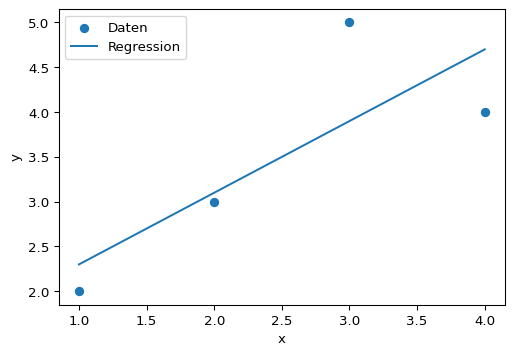

In [125]:
import matplotlib.pyplot as plt

x_plot = X[:, 1]

plt.figure(figsize=(6, 4))
plt.scatter(x_plot, y, label="Daten")
plt.plot(x_plot, y_pred, label="Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Übung 6

1.  Implementiere lineare Regression über die Normalengleichung.
2.  Füge Rauschen zu den Daten hinzu.
3.  Untersuche, wie sich die Lösung verändert.

# 7. Gradientenverfahren

## 7.1 Gradient der quadratischen Verlustfunktion

Für

$$f(w) = \frac{1}{n}\|Xw - y\|_2^2$$

gilt

$$\nabla f(w) = \frac{2}{n} X^\top (Xw - y).$$

## 7.2 Gradient Descent

In [126]:
X = np.array([[1.0, 1.0],
              [1.0, 2.0],
              [1.0, 3.0],
              [1.0, 4.0]])
y = np.array([2.0, 3.0, 5.0, 4.0])

n, d = X.shape
w = np.zeros(d)
eta = 0.1

loss_history = []

for k in range(200):
    grad = (2 / n) * X.T @ (X @ w - y)
    w = w - eta * grad
    loss = np.mean((X @ w - y)**2)
    loss_history.append(loss)

print("Gefundene Parameter:", w)
print("Letzter Loss:", loss_history[-1])

Gefundene Parameter: [1.49747983 0.80085716]
Letzter Loss: 0.45000106073702084

## 7.3 Konvergenz visualisieren

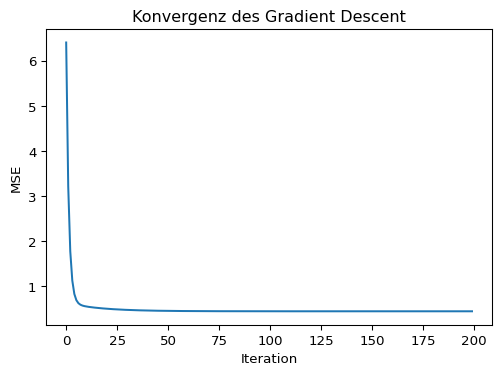

In [127]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Konvergenz des Gradient Descent")
plt.show()

## Übung 7

1.  Experimentiere mit verschiedenen Lernraten `eta`.
2.  Beobachte Konvergenz, langsames Lernen und Divergenz.
3.  Vergleiche die GD-Lösung mit der Lösung aus der Normalengleichung.

# 8. Logistische Regression

## 8.1 Binäre Klassifikation

Wir modellieren Wahrscheinlichkeiten mit der Sigmoid-Funktion

$$\sigma(t) = \frac{1}{1 + e^{-t}}.$$

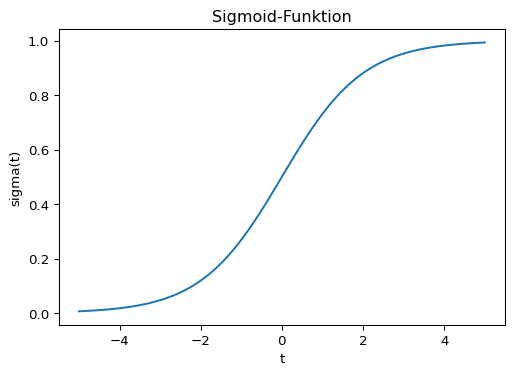

In [128]:
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

t = np.linspace(-5, 5, 100)
plt.figure(figsize=(6, 4))
plt.plot(t, sigmoid(t))
plt.xlabel("t")
plt.ylabel("sigma(t)")
plt.title("Sigmoid-Funktion")
plt.show()

## 8.2 Modell

Für Datenmatrix $X$ und Parameter $w$ gilt

$$p(y=1 \mid x) = \sigma(Xw).$$

## 8.3 Binary Cross Entropy

Die Verlustfunktion ist

$$L(w) = -\frac{1}{n}\sum_{i=1}^n \left(y_i \log p_i + (1-y_i)\log(1-p_i)\right).$$

In [129]:
def binary_cross_entropy(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

## 8.4 Training per Gradient Descent

In [130]:
X_raw = np.array([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0],
                  [1.5, 1.0],
                  [2.0, 1.0]])

y = np.array([0, 0, 0, 1, 1, 1], dtype=float)

X = np.column_stack([np.ones(len(X_raw)), X_raw])

n, d = X.shape
w = np.zeros(d)
eta = 0.5
history = []

for _ in range(1000):
    p = sigmoid(X @ w)
    grad = (X.T @ (p - y)) / n
    w -= eta * grad
    history.append(binary_cross_entropy(y, p))

print("w =", w)
print("finaler Loss =", history[-1])

w = [-8.43141241  5.56359354  5.49551652]
finaler Loss = 0.03031078985439453

## 8.5 Vorhersagen

In [131]:
p = sigmoid(X @ w)
y_pred = (p >= 0.5).astype(int)

print("Wahrscheinlichkeiten:", p)
print("Vorhergesagte Klassen:", y_pred)
print("Trefferquote:", np.mean(y_pred == y))

Wahrscheinlichkeiten: [2.17866013e-04 5.04073600e-02 5.37675122e-02 9.32623019e-01
 9.95546025e-01 9.99723021e-01]
Vorhergesagte Klassen: [0 0 0 1 1 1]
Trefferquote: 1.0

## Übung 8

1.  Implementiere logistische Regression selbst.
2.  Variiere die Lernrate und die Anzahl der Iterationen.
3.  Ersetze die Trainingsdaten durch einen eigenen 2D-Datensatz.

# 9. Shapes, Masking und Datenvorverarbeitung

## 9.1 Reshape

In [132]:
x = np.arange(12)
X = x.reshape(3, 4)

print("x =", x)
print("X =\n", X)

x = [ 0  1  2  3  4  5  6  7  8  9 10 11]
X =
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

## 9.2 Neue Achsen

In [133]:
x = np.array([1.0, 2.0, 3.0])

print("x.shape =", x.shape)
print("x[:, None].shape =", x[:, None].shape)
print("x[None, :].shape =", x[None, :].shape)

x.shape = (3,)
x[:, None].shape = (3, 1)
x[None, :].shape = (1, 3)

## 9.3 Boolean Masking

In [134]:
X = np.array([[1.0, 10.0],
              [-1.0, 20.0],
              [2.0, 30.0],
              [-2.0, 40.0]])

mask = X[:, 0] > 0
print("Maske:", mask)
print("Gefilterte Daten =\n", X[mask])

Maske: [ True False  True False]
Gefilterte Daten =
 [[ 1. 10.]
 [ 2. 30.]]

## Übung 9

1.  Erzeuge einen Datensatz mit positiven und negativen Werten.
2.  Filtere alle Zeilen heraus, deren erste Komponente negativ ist.
3.  Erläutere die Rolle von Masking im Preprocessing.

# 10. Einfaches neuronales Netz

## 10.1 Modellidee

Ein einfaches Netzwerk mit einer versteckten Schicht kann als

$$f(x) = W_2 \,\phi(XW_1 + b_1) + b_2$$

geschrieben werden.

Wir verwenden als Aktivierungsfunktion die ReLU

$$\mathrm{ReLU}(t) = \max(0,t).$$

## 10.2 Forward Pass

In [135]:
def relu(x):
    return np.maximum(0, x)

rng = np.random.default_rng(0)

X = np.array([[0.0, 0.0],
              [0.0, 1.0],
              [1.0, 0.0],
              [1.0, 1.0]])

W1 = rng.standard_normal((2, 4))
b1 = np.zeros(4)
W2 = rng.standard_normal((4, 1))
b2 = np.zeros(1)

H = relu(X @ W1 + b1)
Y = H @ W2 + b2

print("Hidden layer H =\n", H)
print("Output Y =\n", Y)

Hidden layer H =
 [[0.         0.         0.         0.        ]
 [0.         0.36159505 1.30400005 0.94708096]
 [0.12573022 0.         0.64042265 0.10490012]
 [0.         0.22949019 1.9444227  1.05198108]]
Output Y =
 [[ 0.        ]
 [-1.23118103]
 [-0.48330477]
 [-1.45883668]]

## 10.3 Bemerkung zur Backpropagation

Für einen vollständigen Kurs sollte hier die Kettenregel in Matrixform
entwickelt werden.  
In einer ersten Einführung genügt oft:

1.  Vorwärtsdurchlauf definieren,
2.  Verlustfunktion formulieren,
3.  Gradienten der einzelnen Parameter herleiten,
4.  Update-Regel implementieren.

> **Tip**
>
> Gerade für Mathematiker:innen lohnt es sich, Backpropagation als
> wiederholte Anwendung der Kettenregel auf affine Abbildungen und
> nichtlineare Aktivierungen zu präsentieren.

## Übung 10

1.  Implementiere ein kleines neuronales Netz mit einer versteckten
    Schicht.
2.  Verwende ReLU als Aktivierung.
3.  Erzeuge einen kleinen künstlichen Datensatz und berechne den Forward
    Pass.

# 11. Numerische Stabilität

## 11.1 Problem: Overflow bei `exp`

In [136]:
x = np.array([1000.0, 1001.0, 1002.0])

Die naive Softmax-Implementierung

$$\mathrm{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

kann numerisch instabil sein.

## 11.2 Stabile Softmax

In [137]:
def softmax_stable(x):
    z = x - np.max(x)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)

print("stabile Softmax:", softmax_stable(x))

stabile Softmax: [0.09003057 0.24472847 0.66524096]

## Übung 11

1.  Implementiere eine naive Softmax.
2.  Vergleiche sie mit der stabilen Version.
3.  Diskutiere das Problem des Overflows.

# 12. Mini-Projekte

## Projekt A: Lineare Regression

- Simuliere Daten
- fitte ein Modell
- interpretiere die Parameter
- visualisiere Residuen

## Projekt B: Logistische Regression

- konstruiere einen binären Datensatz
- trainiere ein Modell
- berechne Accuracy und Loss

## Projekt C: NumPy-only Neuronales Netz

- ein Hidden Layer
- ReLU oder Sigmoid
- Training mit Gradient Descent
- Diskussion von Overfitting und Lernrate

# 13. Zusammenfassung

Die zentralen NumPy-Ideen für Machine Learning sind:

- **Arrays als Träger mathematischer Objekte**
- **Vektorisierung statt Schleifen**
- **Matrixrechnung für Modelle**
- **statistische Aggregation für Datenanalyse**
- **Gradientenverfahren für Optimierung**
- **Shape-Kompetenz für sauberen Code**
- **numerische Stabilität für robuste Implementierungen**

# 14. Weiterführende Themen

Für einen Anschlusskurs bieten sich an:

- Regularisierung (Ridge, Lasso)
- PCA mit SVD
- stochastischer Gradient Descent
- Mini-Batching
- automatische Differentiation
- Übergang zu PyTorch oder JAX

# Hausaufgabenideen

1.  Implementiere lineare Regression mit und ohne Normalengleichung.
2.  Implementiere logistische Regression für einen selbst erzeugten
    Datensatz.
3.  Untersuche den Einfluss der Lernrate auf die Konvergenz.
4.  Erstelle eine stabile Softmax-Funktion.
5.  Dokumentiere typische Shape-Fehler und ihre Korrektur.

# Literaturhinweise

- NumPy-Dokumentation
- G. Strang: *Linear Algebra and Learning from Data*
- Hastie, Tibshirani, Friedman: *The Elements of Statistical Learning*
- Goodfellow, Bengio, Courville: *Deep Learning*